# Análisis y backtesting de portafolios de inversión

**Autor: Alberto José Corella Moreno**  
**Informe de cierre · muestra del 4 de enero de 2010 al 31 de diciembre de 2025**

Este estudio evalúa cómo la diversificación y las reglas de rebalanceo modifican
el crecimiento, las caídas y la composición de un portafolio. El universo reúne
cuatro exposiciones mediante instrumentos cotizados en USD:

| Símbolo | Exposición representada |
|---|---|
| SPY | Acciones estadounidenses del S&P 500. |
| IEF | Bonos del Tesoro de Estados Unidos con vencimientos de 7 a 10 años. |
| GLD | Oro. |
| VNQ | Renta variable del sector inmobiliario estadounidense, incluidos REIT. |

La asignación de referencia establece un **25% por activo**. A partir de ella se
comparan mantener posiciones, rebalancear por calendario y actuar ante desviaciones
de los pesos. El análisis incorpora costos proporcionales, distintas fechas de
entrada, ejecución diferida y una referencia histórica libre de riesgo en USD.
SPY permite valorar el intercambio frente a una inversión concentrada en acciones;
las comparaciones entre reglas del portafolio mantienen el mismo universo inicial.

El resultado central es un intercambio entre crecimiento y control de la exposición.
La cartera mensual reduce volatilidad y caída máxima frente a SPY, a cambio de
menor crecimiento compuesto. Las bandas disminuyen la actividad de rebalanceo;
su ventaja histórica en rendimiento ajustado por riesgo es pequeña y cambia según
el periodo. La evidencia permite evaluar estas decisiones de gestión, sin identificar
una regla universalmente superior.

**Alcance de la lectura.** Las cifras de los textos corresponden a la copia de datos
guardada y a los parámetros documentados: 10,000 USD iniciales, pesos de 25% y
10 puntos base por importe comprado o vendido. Son conclusiones de esta ejecución;
si se cambian datos o parámetros, deben revisarse junto con las nuevas salidas.
Las secciones 2–6 usan el mismo cierre; las secciones 7–8 distinguen explícitamente
la ejecución al cierre de la siguiente sesión.

**Datos y reproducción.** La celda siguiente documenta la descarga con `yfinance`
y sobrescribe los CSV locales. Para reproducir la muestra guardada, se inicia en
la celda de carga y validación de CSV de la sección 1 y se continúa en orden hasta
el final. El [README](README.md) reúne los requisitos, comandos y fuentes.

In [1]:
from pathlib import Path
import yfinance as yf

tickers = ["SPY", "IEF", "GLD", "VNQ"]

datos = yf.download(
    tickers,
    start="2010-01-01",
    end="2026-01-01",       # La fecha final es exclusiva
    interval="1d",
    auto_adjust=False,     # Conservar Close y Adj Close por separado
    actions=True,          # Incluir dividendos y splits
    progress=False,
)

if datos is None or datos.empty:
    raise RuntimeError("La descarga no devolvió datos. Inténtalo nuevamente.")

# Una columna por activo y una fila por fecha
precios = datos["Adj Close"].reindex(columns=tickers)

print("Primeras filas:")
print(precios.head())

print("\nDatos faltantes por activo:")
print(precios.isna().sum())

if precios.isna().any().any():
    raise ValueError("Revisa los datos faltantes antes de calcular rendimientos.")

# Rendimiento diario: precio de hoy / precio anterior - 1
rendimientos = precios.pct_change(fill_method=None).iloc[1:]

# Guardar una copia local para trabajar sin descargar cada vez
carpeta = Path("data")
carpeta.mkdir(exist_ok=True)

datos.to_csv(carpeta / "historico_descargado.csv")
precios.to_csv(carpeta / "precios_ajustados.csv")
rendimientos.to_csv(carpeta / "rendimientos_diarios.csv")

print("\nPeríodo:", precios.index.min(), "a", precios.index.max())
print("Número de observaciones:", len(precios))

Primeras filas:
Ticker            SPY        IEF         GLD        VNQ
Date                                                   
2010-01-04  84.368988  60.713737  109.800003  23.145582
2010-01-05  84.592308  60.980282  109.699997  23.119602
2010-01-06  84.651894  60.734192  111.510002  23.078043
2010-01-07  85.009201  60.734192  110.820000  23.327410
2010-01-08  85.292091  60.809387  111.370003  23.155966

Datos faltantes por activo:
Ticker
SPY    0
IEF    0
GLD    0
VNQ    0
dtype: int64

Período: 2010-01-04 00:00:00 a 2025-12-31 00:00:00
Número de observaciones: 4024


## 1. Análisis exploratorio por activo

La exploración establece el punto de partida económico del portafolio: cuánto
creció cada exposición, qué variación diaria presentó y qué pérdidas desde máximos
experimentó. Se utilizan **4,024 precios ajustados y 4,023 rendimientos diarios por
activo**, con fechas comunes entre el 04/01/2010 y el 31/12/2025.

La validación comprueba fechas ordenadas y únicas, precios positivos, ausencia de
valores no finitos y consistencia entre los rendimientos guardados y los calculados
a partir de precios. Estos controles verifican la coherencia interna de la muestra;
no sustituyen una auditoría del proveedor ni de cada sesión del calendario bursátil.

Los rendimientos son nominales en USD. Se emplea `Adj Close` de Yahoo Finance a
través de `yfinance`, tomando los ajustes del proveedor como aproximación al retorno
con distribuciones y eventos corporativos incorporados. No se agregan dividendos
por separado. En esta sección se estudian inversiones individuales sin cargos
de negociación; los costos del portafolio se incorporan desde la sección 2.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

tickers = ["SPY", "IEF", "GLD", "VNQ"]
carpeta = Path("data")
precios = pd.read_csv(
    carpeta / "precios_ajustados.csv", index_col="Date", parse_dates=["Date"]
)
rendimientos = pd.read_csv(
    carpeta / "rendimientos_diarios.csv", index_col="Date", parse_dates=["Date"]
)

for nombre, tabla in [("precios", precios), ("rendimientos", rendimientos)]:
    if list(tabla.columns) != tickers:
        raise ValueError(f"Columnas inesperadas en {nombre}: {list(tabla.columns)}")
    if not isinstance(tabla.index, pd.DatetimeIndex) or tabla.index.hasnans:
        raise ValueError(f"Fechas inválidas en {nombre}.")
    if not tabla.index.is_unique or not tabla.index.is_monotonic_increasing:
        raise ValueError(f"Las fechas de {nombre} deben ser únicas y estar ordenadas.")
    if not np.isfinite(tabla.to_numpy(dtype=float)).all():
        raise ValueError(f"Hay datos faltantes o no finitos en {nombre}.")

if len(precios) < 3 or (precios <= 0).any().any():
    raise ValueError("Se requieren al menos tres observaciones de precios positivos.")

rendimientos_calculados = precios.pct_change(fill_method=None).iloc[1:]
if not rendimientos.index.equals(rendimientos_calculados.index):
    raise ValueError("Las fechas de rendimientos no corresponden a las de precios.")
if not np.allclose(rendimientos, rendimientos_calculados, rtol=1e-9, atol=1e-12):
    raise ValueError("Los rendimientos guardados no coinciden con los precios.")

print(f"Periodo: {precios.index[0]:%Y-%m-%d} a {precios.index[-1]:%Y-%m-%d}")
print(f"Observaciones: {len(precios):,} precios y {len(rendimientos):,} rendimientos por activo.")
print("Validación correcta: fechas, valores y consistencia entre ambos archivos.")

Periodo: 2010-01-04 a 2025-12-31
Observaciones: 4,024 precios y 4,023 rendimientos por activo.
Validación correcta: fechas, valores y consistencia entre ambos archivos.


### Definiciones de rendimiento y riesgo

La evaluación combina crecimiento compuesto con medidas de variación y pérdida:

- **Rendimiento acumulado:** razón entre el último y el primer precio ajustado,
  menos uno.
- **CAGR:** tasa anual compuesta equivalente al crecimiento observado, utilizando
  la duración efectiva en días calendario divididos entre 365.25.
- **Volatilidad anualizada:** desviación estándar muestral de los rendimientos
  diarios, multiplicada por $\sqrt{252}$.
- **Máxima caída:** menor valor de $P_t/\max_{s\leq t}P_s-1$. Se expresa con signo
  negativo; cuanto más negativo, mayor pérdida desde un máximo anterior.
- **Mejor y peor día:** extremos de los rendimientos de una sesión presentes en la muestra.

Estas medidas responden a preguntas distintas. El CAGR resume acumulación de
riqueza y no equivale al promedio diario multiplicado por 252; la volatilidad no
describe por sí sola la profundidad ni la persistencia de las pérdidas. Los ratios
Sharpe y Sortino se incorporan en la sección 8 con una referencia diaria común.

In [3]:
SESIONES_ANUALES = 252
anios = (precios.index[-1] - precios.index[0]).days / 365.25

# Base 100 incluye la fecha inicial para medir también las primeras caídas.
crecimiento = precios.div(precios.iloc[0]).mul(100)
drawdowns = crecimiento.div(crecimiento.cummax()).sub(1)
correlaciones = rendimientos.corr()

metricas = pd.DataFrame({
    "Rendimiento acumulado": precios.iloc[-1].div(precios.iloc[0]).sub(1),
    "CAGR": precios.iloc[-1].div(precios.iloc[0]).pow(1 / anios).sub(1),
    "Volatilidad anualizada": rendimientos.std(ddof=1) * np.sqrt(SESIONES_ANUALES),
    "Máxima caída": drawdowns.min(),
    "Mejor día": rendimientos.max(),
    "Peor día": rendimientos.min(),
}).reindex(tickers)
metricas.index.name = "Activo"

# El formato cambia la presentación; los valores se conservan como decimales.
display(metricas.style.format("{:.2%}").set_caption(
    "Desempeño histórico por activo · precios ajustados en USD"
))

,Rendimiento acumulado,CAGR,Volatilidad anualizada,Máxima caída,Mejor día,Peor día
Activo,,,,,,
SPY,701.99%,13.91%,17.21%,-33.72%,10.50%,-10.94%
IEF,54.25%,2.75%,6.63%,-23.92%,2.64%,-2.51%
GLD,260.94%,8.36%,15.82%,-45.56%,4.90%,-8.78%
VNQ,271.75%,8.56%,20.50%,-42.40%,9.10%,-17.73%


### Trayectorias de crecimiento y pérdidas desde máximos

La normalización a **100 unidades iniciales por activo** permite comparar riqueza
acumulada sobre una base homogénea. La gráfica de caídas complementa esa vista:
un valor de cero indica un máximo de la serie observada y los valores negativos
representan pérdidas frente al máximo alcanzado hasta ese momento.

SPY registra el mayor crecimiento del periodo, pero su caída máxima alcanza
**−33.72%**. GLD y VNQ presentan caídas de **−45.56%** y **−42.40%**, respectivamente.
IEF combina menor volatilidad con una caída máxima de **−23.92%**. Esta diferencia
entre variación diaria y pérdida acumulada muestra por qué una exposición menos
volátil tampoco equivale a preservar el capital en todo horizonte.

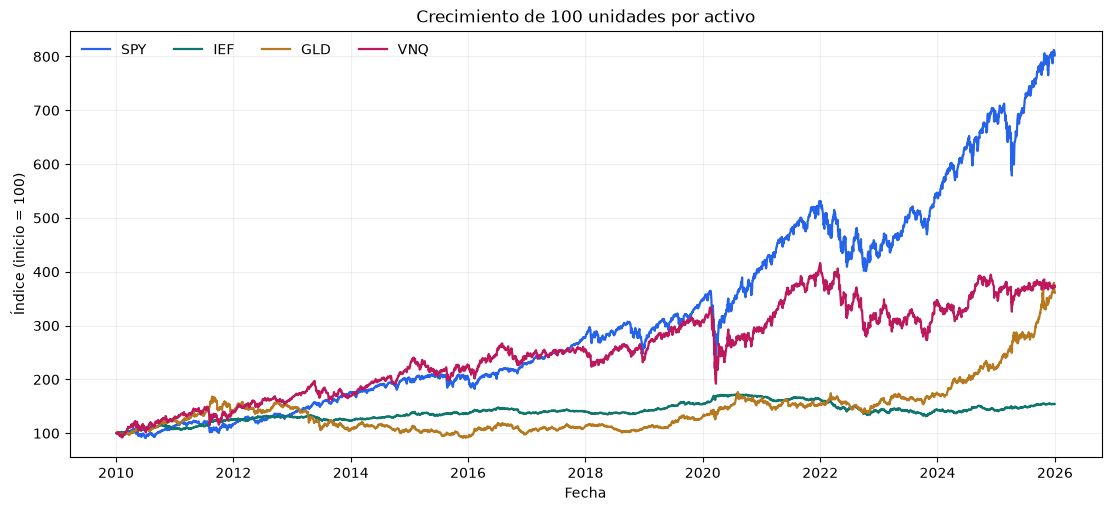

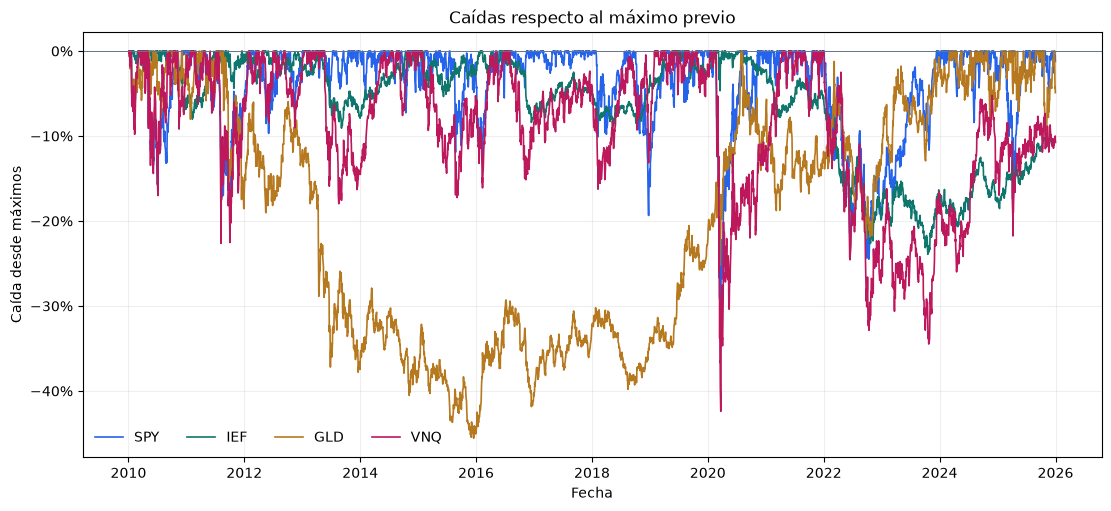

In [4]:
colores = {"SPY": "#2563eb", "IEF": "#0f766e", "GLD": "#b7791f", "VNQ": "#be185d"}

fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
for ticker in tickers:
    ax.plot(crecimiento.index, crecimiento[ticker], label=ticker, color=colores[ticker], lw=1.6)
ax.set(title="Crecimiento de 100 unidades por activo", xlabel="Fecha", ylabel="Índice (inicio = 100)")
ax.grid(alpha=0.2)
ax.legend(ncol=4, loc="upper left", frameon=False)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
for ticker in tickers:
    ax.plot(drawdowns.index, drawdowns[ticker], label=ticker, color=colores[ticker], lw=1.2)
ax.axhline(0, color="#64748b", lw=0.7)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set(title="Caídas respecto al máximo previo", xlabel="Fecha", ylabel="Caída desde máximos")
ax.grid(alpha=0.2)
ax.legend(ncol=4, loc="lower left", frameon=False)
plt.show()

### Dependencia entre los rendimientos

La correlación de Pearson mide asociación lineal entre rendimientos diarios y
se expresa como **coeficiente entre −1 y +1**, no como porcentaje. Una relación
cercana a cero no implica independencia; además, el promedio de toda la muestra
puede ocultar cambios de dependencia dentro del periodo.

SPY y VNQ presentan la mayor correlación positiva, **0.75**, de modo que estas
dos exposiciones aportan movimientos parcialmente coincidentes. SPY e IEF muestran
una correlación de **−0.26**; SPY–GLD, IEF–VNQ y GLD–VNQ registran aproximadamente
**0.05, −0.04 y 0.12**, respectivamente. Estas diferencias justifican analizar
su combinación. La correlación describe movimientos conjuntos: no indica el
rendimiento que obtendrá la cartera ni garantiza protección durante una caída.

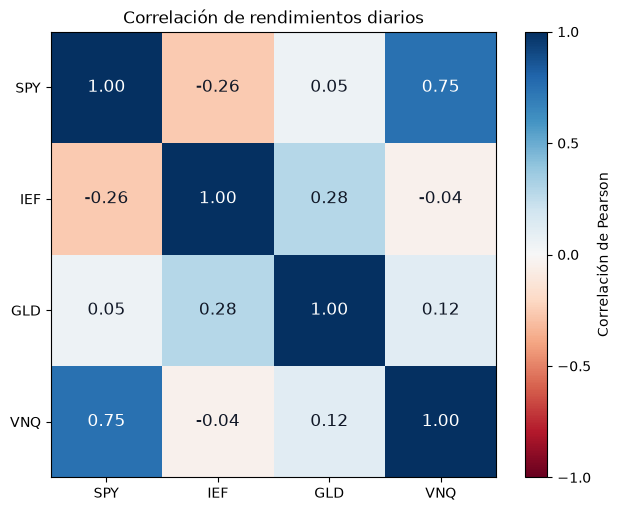

In [5]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
mapa = ax.imshow(correlaciones, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(tickers)), labels=tickers)
ax.set_yticks(range(len(tickers)), labels=tickers)
for fila in range(len(tickers)):
    for columna in range(len(tickers)):
        valor = correlaciones.iloc[fila, columna]
        etiqueta = f"{valor:.2f}" if np.isfinite(valor) else "n.d."
        ax.text(columna, fila, etiqueta, ha="center", va="center",
                color="white" if abs(valor) > 0.6 else "#111827", fontsize=12)
ax.set_title("Correlación de rendimientos diarios")
fig.colorbar(mapa, ax=ax, label="Correlación de Pearson", ticks=[-1, -0.5, 0, 0.5, 1])
plt.show()

### Interpretación del universo de inversión

SPY alcanza un CAGR de **13.91%**, frente a **8.56% en VNQ**, **8.36% en GLD** y
**2.75% en IEF**. La mayor volatilidad corresponde a VNQ (**20.50%**), seguido de
SPY (**17.21%**), GLD (**15.82%**) e IEF (**6.63%**). El orden por crecimiento,
por volatilidad y por caída máxima no es el mismo.

El universo ofrece exposiciones con comportamientos suficientemente distintos
para estudiar la diversificación. Su contribución depende de los pesos y de las
covariaciones, por lo que asignar 25% del capital a cada activo no implica repartir
el riesgo en partes iguales. Tampoco se ha estimado aquí una cartera óptima.

La pregunta que guía el backtest es cómo se transforma este conjunto de activos
al mantener una asignación objetivo y pagar por restaurarla. La comparación
posterior permite observar el costo en crecimiento de reducir la concentración,
así como el grado de reducción de volatilidad y caídas realmente alcanzado.

## 2. Simulación del portafolio con rebalanceo mensual

El caso base mantiene un objetivo de **25% en cada ETF** y lo contrasta con comprar
y mantener SPY. La asignación permanece fija como regla de decisión, mientras los
pesos efectivos cambian diariamente con los precios. Las convenciones del caso
base se resumen a continuación; los cambios de cada experimento posterior se
indican en su sección:

| Elemento | Tratamiento |
|---|---|
| Capital y flujos | 10,000 USD iniciales; sin aportaciones ni retiros. |
| Posiciones | Participaciones fraccionarias, sin ventas en corto ni apalancamiento. |
| Costo base | 10 pb = 0.10% sobre cada importe comprado o vendido; incluye entrada. |
| Rebalanceo mensual | Retorno a los pesos objetivo al último cierre disponible de cada mes, después del rendimiento de esa sesión. |
| Fin de muestra | Sin rebalanceo en la última fecha y sin liquidación de posiciones. |
| Valuación | Precios ajustados; dividendos incorporados una sola vez. |
| Moneda | USD nominales, sin impuestos, inflación ni conversión a MXN. |

Los costos son un supuesto proporcional ilustrativo, no una tarifa observada de
un intermediario. Se pagan con el patrimonio de la cartera. El valor final es una
valuación de las posiciones abiertas y no incluye un costo de venta de salida.

El caso base supone ejecución al mismo cierre utilizado para valuar y restaurar
los pesos. Los nuevos pesos afectan al siguiente intervalo de rendimiento; aun así,
conocer ese cierre y ejecutar exactamente a él constituye una idealización. La
sección 7 evalúa explícitamente un retraso de una sesión. Se simula también la
cartera a costo cero para cuantificar el efecto del supuesto de negociación.

In [6]:
CAPITAL_INICIAL = 10_000.0
COSTO_BPS = 10.0  # 1 punto base = 0.01%; 10 puntos base = 0.10%
PESOS_OBJETIVO = pd.Series({"SPY": 0.25, "IEF": 0.25, "GLD": 0.25, "VNQ": 0.25})

### Autofinanciación y registro de operaciones

Si $h_i$ representa el valor de cada posición antes de operar, $w_i$ su peso objetivo
y $c$ el costo proporcional, el patrimonio posterior debe satisfacer:

$$V_{\mathrm{neto}}+c\sum_i|w_iV_{\mathrm{neto}}-h_i|=\sum_i h_i.$$

El motor resuelve esta identidad por bisección y asigna $w_iV_{\mathrm{neto}}$ a
cada activo. Así, la restauración de pesos y el pago de cargos se realizan con los
recursos existentes. En la entrada, el importe invertido es $C_0/(1+c)$. Este
tratamiento es consistente con la condición de autofinanciación descrita por
[Boyd et al., sección 2.5](https://stanford.edu/~boyd/papers/pdf/cvx_portfolio.pdf).

El registro conserva fecha, motivo, compras, ventas, costo y valores anteriores
y posteriores. **Volumen operado** significa compras más ventas, sin dividir
entre dos. Esta definición permite comprobar el cargo sobre ambos lados de una
reasignación y distinguir actividad de negociación de rendimiento del portafolio.

In [7]:
# Motor del backtest: funciones independientes de las salidas del notebook.
import numpy as np
import pandas as pd


def simular_portafolio(precios, pesos, capital_inicial=10_000.0,
                       costo_bps=10.0, rebalanceo_mensual=True, *, frecuencia=None, banda_pp=None,
                       ejecucion="mismo_cierre"):
    '''Simula inversiones con costos y rebalanceos al cierre actual o siguiente.

    La compra inicial siempre se realiza al primer cierre. En modo diferido, una
    señal interior se ejecuta al cierre siguiente con las posiciones entonces
    vigentes, incluso si el desvío ya volvió dentro de banda. No se rebalancea en
    el cierre final; esa señal queda registrada como no ejecutable en la muestra.
    '''
    if not isinstance(ejecucion, str) or ejecucion not in ["mismo_cierre", "siguiente_cierre"]:
        raise ValueError("Ejecución válida: mismo_cierre o siguiente_cierre.")
    if not isinstance(precios.index, pd.DatetimeIndex) or precios.index.hasnans:
        raise ValueError("El índice debe contener fechas válidas.")
    if len(precios) < 3 or not precios.index.is_unique or not precios.index.is_monotonic_increasing:
        raise ValueError("Se requieren al menos tres fechas únicas y ordenadas.")
    if not precios.columns.is_unique or precios.shape[1] == 0:
        raise ValueError("Los activos deben ser únicos y no estar vacíos.")
    matriz = precios.to_numpy(dtype=float)
    if not np.isfinite(matriz).all() or (matriz <= 0).any():
        raise ValueError("Los precios deben ser positivos y finitos.")
    pesos = pd.Series(pesos, dtype=float)
    if not pesos.index.is_unique or set(pesos.index) != set(precios.columns):
        raise ValueError("Los pesos deben identificar exactamente los activos de precios.")
    objetivo = pesos.reindex(precios.columns).to_numpy()
    if not np.isfinite(objetivo).all() or (objetivo < 0).any():
        raise ValueError("Los pesos deben ser finitos y no negativos.")
    if not np.isclose(objetivo.sum(), 1.0, rtol=0, atol=1e-12):
        raise ValueError("Los pesos deben sumar 1.")
    objetivo = objetivo / objetivo.sum()  # Elimina únicamente redondeo numérico.
    if not np.isfinite(capital_inicial) or capital_inicial <= 0:
        raise ValueError("El capital inicial debe ser positivo y finito.")
    if not np.isfinite(costo_bps) or not 0 <= costo_bps < 10_000:
        raise ValueError("El costo debe estar entre 0 y menos de 10,000 puntos base.")
    tasa = costo_bps / 10_000
    fechas = precios.index
    # Sin frecuencia explícita se conserva el comportamiento de las llamadas anteriores.
    if frecuencia is None:
        frecuencia = "mensual" if rebalanceo_mensual else "sin rebalanceo"
    periodos = {"mensual": "M", "trimestral": "Q-DEC", "anual": "Y-DEC"}
    if frecuencia not in ["sin rebalanceo", "bandas", *periodos]:
        raise ValueError("Frecuencia válida: sin rebalanceo, mensual, trimestral, anual o bandas.")
    if frecuencia == "bandas":
        if (isinstance(banda_pp, (bool, np.bool_))
                or not isinstance(banda_pp, (int, float, np.integer, np.floating))
                or not np.isfinite(banda_pp) or not 0 < banda_pp < 100):
            raise ValueError("Para bandas se requiere banda_pp numérica, finita y entre 0 y 100, sin incluir extremos.")
    elif banda_pp is not None:
        raise ValueError("banda_pp solo se utiliza con frecuencia='bandas'.")
    if frecuencia in ["sin rebalanceo", "bandas"]:
        fechas_rebalanceo = set()
    else:
        cierres = pd.Series(fechas, index=fechas).groupby(
            fechas.to_period(periodos[frecuencia])
        ).last()
        fechas_rebalanceo = set(cierres[(cierres > fechas[0]) & (cierres < fechas[-1])])

    valores = np.empty(len(fechas))
    pesos_despues = np.empty_like(matriz)
    pesos_antes = np.empty_like(matriz)
    costos = np.zeros(len(fechas))
    operaciones = []
    senales = []
    pendiente = None

    invertido = capital_inicial / (1 + tasa)
    posiciones = objetivo * invertido
    costos[0] = capital_inicial - invertido
    valores[0] = invertido
    pesos_antes[0] = objetivo
    pesos_despues[0] = objetivo
    operaciones.append({
        "Fecha": fechas[0], "Motivo": "Compra inicial", "Valor antes": capital_inicial,
        "Valor después": invertido, "Compras": invertido, "Ventas": 0.0,
        "Volumen operado": invertido, "Costo": costos[0],
        "Volumen / patrimonio": invertido / capital_inicial,
    })

    for i in range(1, len(fechas)):
        # Primero ganan o pierden las posiciones existentes; luego se opera al cierre.
        posiciones = posiciones * (matriz[i] / matriz[i - 1])
        valor_antes = posiciones.sum()
        pesos_antes[i] = posiciones / valor_antes
        # Revisión diaria al cierre; igualdad al límite no dispara una operación.
        fuera_de_banda = (frecuencia == "bandas" and i < len(fechas) - 1
                          and np.max(np.abs(pesos_antes[i] - objetivo)) > banda_pp / 100 + 1e-12)
        operar = ((fechas[i] in fechas_rebalanceo or fuera_de_banda)
                  if ejecucion == "mismo_cierre" else pendiente is not None)
        if operar:
            if tasa == 0 or np.max(np.abs(pesos_antes[i] - objetivo)) < 1e-14:
                valor_neto = valor_antes
            else:
                inferior, superior = 0.0, valor_antes
                for _ in range(60):
                    medio = (inferior + superior) / 2
                    balance = medio + tasa * np.abs(objetivo * medio - posiciones).sum()
                    if balance > valor_antes:
                        superior = medio
                    else:
                        inferior = medio
                valor_neto = (inferior + superior) / 2
            nuevas_posiciones = objetivo * valor_neto
            cambios = nuevas_posiciones - posiciones
            compras = np.maximum(cambios, 0).sum()
            ventas = np.maximum(-cambios, 0).sum()
            costos[i] = tasa * (compras + ventas)
            if not np.isclose(valor_neto + costos[i], valor_antes, rtol=1e-12, atol=1e-9):
                raise ArithmeticError("No se cumple el balance después de costos.")
            posiciones = nuevas_posiciones
            operaciones.append({
                "Fecha": fechas[i], "Motivo": (f"Rebalanceo por bandas ({banda_pp:g} pp)" if frecuencia == "bandas"
                                             else f"Rebalanceo {frecuencia}"), "Valor antes": valor_antes,
                "Valor después": valor_neto, "Compras": compras, "Ventas": ventas,
                "Volumen operado": compras + ventas, "Costo": costos[i],
                "Volumen / patrimonio": (compras + ventas) / valor_antes,
            })
            if ejecucion == "siguiente_cierre":
                senales[pendiente]["Fecha ejecución"] = fechas[i]
                senales[pendiente]["Estado"] = "Ejecutada"
                pendiente = None
        valores[i] = posiciones.sum()
        pesos_despues[i] = posiciones / valores[i]

        if ejecucion == "siguiente_cierre" and i < len(fechas) - 1:
            # Detectar después de ejecutar evita otra señal por pesos ya corregidos.
            desvio = np.max(np.abs(pesos_despues[i] - objetivo))
            nueva_senal = (fechas[i] in fechas_rebalanceo
                           or (frecuencia == "bandas" and desvio > banda_pp / 100 + 1e-12))
            if nueva_senal:
                ejecutable = i + 1 < len(fechas) - 1
                senales.append({
                    "Fecha señal": fechas[i], "Fecha ejecución prevista": fechas[i + 1],
                    "Fecha ejecución": pd.NaT,
                    "Estado": "Pendiente" if ejecutable else "Sin sesión interior para ejecutar",
                    "Motivo": (f"Rebalanceo por bandas ({banda_pp:g} pp)" if frecuencia == "bandas"
                               else f"Rebalanceo {frecuencia}"),
                    "Desvío señal (pp)": desvio * 100,
                })
                if ejecutable:
                    pendiente = len(senales) - 1

    patrimonio = pd.Series(valores, index=fechas, name="Patrimonio")
    retorno = patrimonio.pct_change(fill_method=None)
    retorno.iloc[0] = patrimonio.iloc[0] / capital_inicial - 1  # Costo de entrada.
    # Incluir el capital antes de comprar evita ocultar la pérdida inicial por costos.
    maximos = patrimonio.cummax().clip(lower=capital_inicial)
    resultado = {
        "patrimonio": patrimonio,
        "rendimientos": retorno,
        "drawdown": patrimonio / maximos - 1,
        "pesos": pd.DataFrame(pesos_despues, index=fechas, columns=precios.columns),
        "pesos_antes": pd.DataFrame(pesos_antes, index=fechas, columns=precios.columns),
        "costos": pd.Series(costos, index=fechas, name="Costo"),
        "operaciones": pd.DataFrame(operaciones).set_index("Fecha"),
        "capital_inicial": capital_inicial,
    }
    if ejecucion == "siguiente_cierre":
        resultado["senales"] = pd.DataFrame(senales, columns=[
            "Fecha señal", "Fecha ejecución prevista", "Fecha ejecución",
            "Estado", "Motivo", "Desvío señal (pp)",
        ])
    return resultado


def resumir_backtest(resultado):
    patrimonio = resultado["patrimonio"]
    capital = resultado["capital_inicial"]
    anios = (patrimonio.index[-1] - patrimonio.index[0]).days / 365.25
    # El primer registro contiene solo la comisión inicial, no una sesión de mercado.
    retornos_diarios = resultado["rendimientos"].iloc[1:]
    return pd.Series({
        "Valor final (USD)": patrimonio.iloc[-1],
        "Rendimiento acumulado": patrimonio.iloc[-1] / capital - 1,
        "CAGR": (patrimonio.iloc[-1] / capital) ** (1 / anios) - 1,
        "Volatilidad anualizada": retornos_diarios.std(ddof=1) * np.sqrt(252),
        "Máxima caída": resultado["drawdown"].min(),
        "Costos pagados (USD)": resultado["costos"].sum(),
        "Rebalanceos": int(resultado["operaciones"]["Motivo"].str.startswith("Rebalanceo ").sum()),
    })

In [8]:
portafolio_neto = simular_portafolio(precios, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTO_BPS)
portafolio_bruto = simular_portafolio(precios, PESOS_OBJETIVO, CAPITAL_INICIAL, 0.0)
referencia_spy = simular_portafolio(
    precios[["SPY"]], {"SPY": 1.0}, CAPITAL_INICIAL, COSTO_BPS, rebalanceo_mensual=False
)
resultados_backtest = {
    "Portafolio neto": portafolio_neto,
    "Portafolio sin costos": portafolio_bruto,
    "SPY neto": referencia_spy,
}
resumen_backtest = pd.DataFrame({
    nombre: resumir_backtest(resultado) for nombre, resultado in resultados_backtest.items()
}).T
resumen_backtest.index.name = "Estrategia"
formato_backtest = {
    "Valor final (USD)": "{:,.2f}", "Rendimiento acumulado": "{:.2%}", "CAGR": "{:.2%}",
    "Volatilidad anualizada": "{:.2%}", "Máxima caída": "{:.2%}",
    "Costos pagados (USD)": "{:,.2f}", "Rebalanceos": "{:.0f}",
}
print(f"Capital inicial: {CAPITAL_INICIAL:,.2f} USD | Costo: {COSTO_BPS:g} pb por importe operado")
print(f"Periodo: {precios.index[0]:%Y-%m-%d} a {precios.index[-1]:%Y-%m-%d}")
display(resumen_backtest.style.format(formato_backtest).set_caption(
    "Comparación de estrategias · misma muestra y capital inicial"
))

Capital inicial: 10,000.00 USD | Costo: 10 pb por importe operado
Periodo: 2010-01-04 a 2025-12-31


,Valor final (USD),Rendimiento acumulado,CAGR,Volatilidad anualizada,Máxima caída,Costos pagados (USD),Rebalanceos
Estrategia,,,,,,,
Portafolio neto,"38,991.30",289.91%,8.88%,9.95%,-21.10%,99.56,191
Portafolio sin costos,"39,204.49",292.04%,8.92%,9.95%,-21.08%,0.00,191
SPY neto,"80,119.37",701.19%,13.90%,17.21%,-33.72%,9.99,0


### Cómo se incorpora el costo al desempeño

El rendimiento acumulado, CAGR y caída máxima incluyen la compra inicial y los
rebalanceos. La máxima caída se calcula incorporando el capital previo a la entrada,
de modo que la comisión inicial no desaparezca de la medición. La volatilidad de
estas secciones utiliza los intervalos entre cierres y excluye el registro aislado
de la comisión de entrada, que no representa una sesión de mercado. La sección 8
integra ese cargo en el primer intervalo real para calcular Sharpe y Sortino.

También se distinguen dos efectos monetarios: **costos pagados** es la suma de
cargos nominales; **impacto en el valor final** es la diferencia frente a la misma
regla sin costos e incorpora la capitalización que se dejó de obtener. En el caso
mensual, ambas magnitudes son **99.56 USD** y **213.19 USD**, respectivamente.

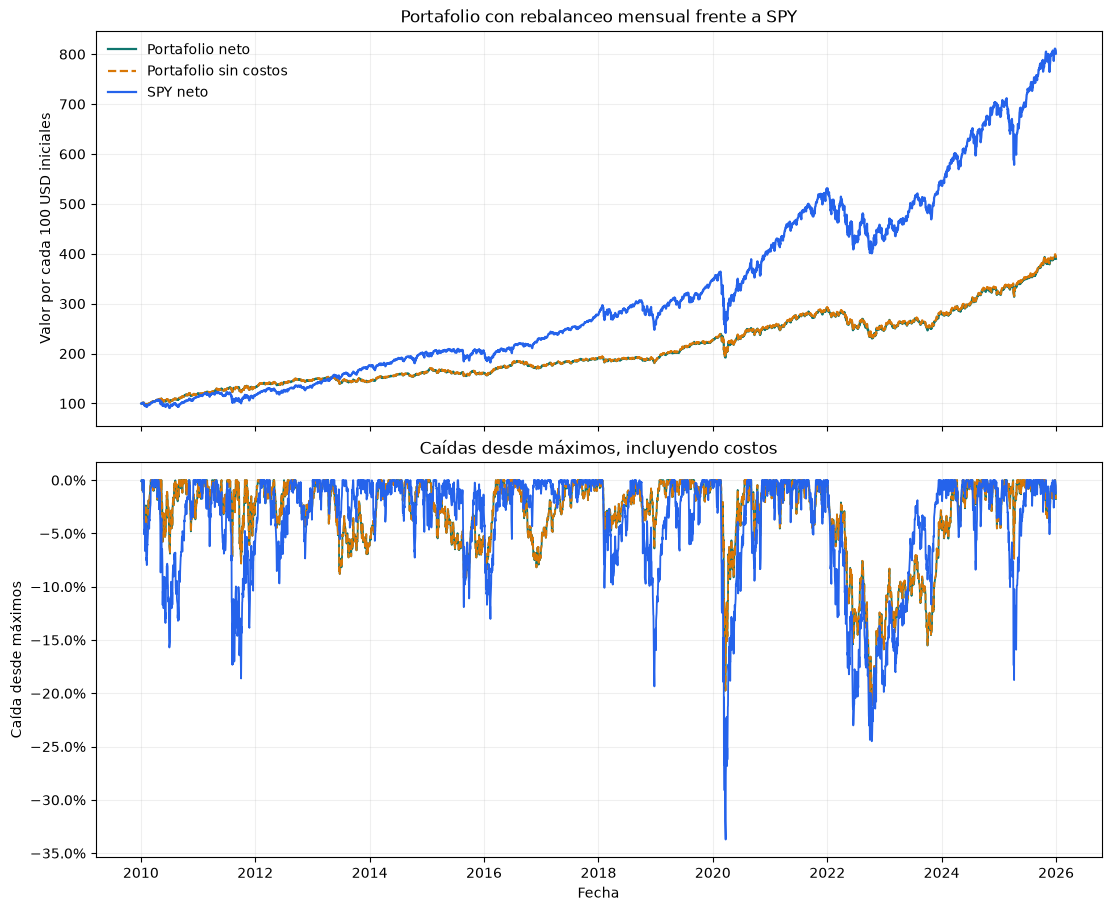

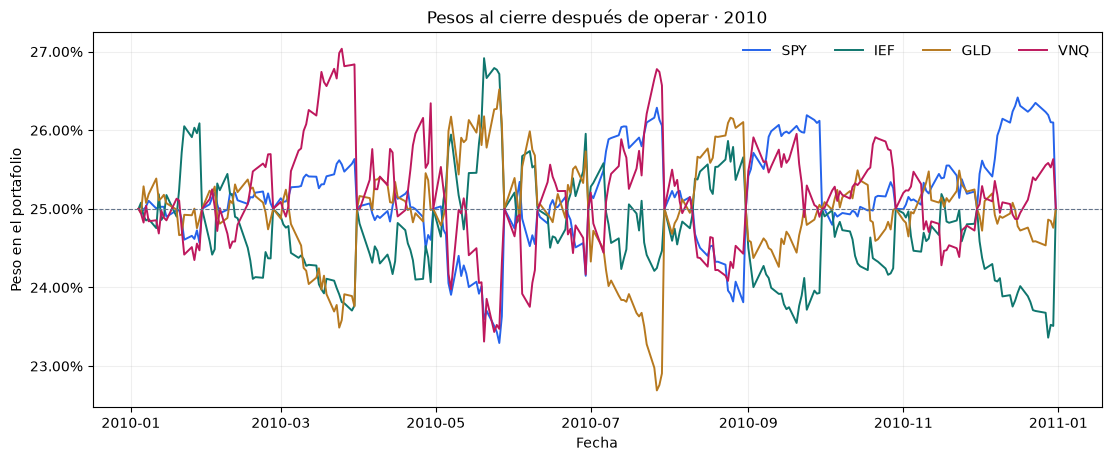

In [9]:
patrimonios = pd.DataFrame({nombre: r["patrimonio"] for nombre, r in resultados_backtest.items()})
caidas_backtest = pd.DataFrame({nombre: r["drawdown"] for nombre, r in resultados_backtest.items()})
estilos = {
    "Portafolio neto": ("#0f766e", "-"),
    "Portafolio sin costos": ("#d97706", "--"),
    "SPY neto": ("#2563eb", "-"),
}
fig, ejes = plt.subplots(2, 1, figsize=(11, 9), sharex=True, layout="constrained")
for nombre, (color, estilo) in estilos.items():
    ejes[0].plot(patrimonios.index, patrimonios[nombre] / CAPITAL_INICIAL * 100,
                 label=nombre, color=color, ls=estilo, lw=1.6)
    ejes[1].plot(caidas_backtest.index, caidas_backtest[nombre],
                 label=nombre, color=color, ls=estilo, lw=1.3)
ejes[0].set(title="Portafolio con rebalanceo mensual frente a SPY", ylabel="Valor por cada 100 USD iniciales")
ejes[0].legend(loc="upper left", frameon=False)
ejes[1].set(title="Caídas desde máximos, incluyendo costos", ylabel="Caída desde máximos", xlabel="Fecha")
ejes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in ejes:
    ax.grid(alpha=0.2)
plt.show()

# Mostrar un año permite ver la deriva diaria y el retorno al 25% al cierre de mes.
primer_anio = precios.index[0].year
pesos_muestra = portafolio_neto["pesos"].loc[str(primer_anio)]
fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
for ticker, color in {"SPY": "#2563eb", "IEF": "#0f766e", "GLD": "#b7791f", "VNQ": "#be185d"}.items():
    ax.plot(pesos_muestra.index, pesos_muestra[ticker], label=ticker, color=color, lw=1.4)
for peso in PESOS_OBJETIVO.unique():
    ax.axhline(peso, color="#64748b", ls="--", lw=0.8)
ax.set(title=f"Pesos al cierre después de operar · {primer_anio}", ylabel="Peso en el portafolio", xlabel="Fecha")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(ncol=4, frameon=False)
ax.grid(alpha=0.2)
plt.show()

### Trazabilidad y controles contables

La cartera registra **191 rebalanceos mensuales**, además de la compra inicial.
El extracto permite revisar las primeras y últimas operaciones; el detalle completo
se conserva en `portafolio_neto["operaciones"]`. Los pesos diarios antes y después
de negociar están disponibles en `pesos_antes` y `pesos`.

Los controles verifican que el patrimonio posterior más los costos coincida con
el valor anterior, que los cargos correspondan al volumen negociado y que cada
rebalanceo restaure el objetivo. Estas identidades respaldan la coherencia del
motor bajo sus supuestos; su cumplimiento no valida por sí solo la capacidad de
ejecutar esas operaciones a los precios utilizados.

In [10]:
operaciones = portafolio_neto["operaciones"]
fechas_rb = operaciones.index[operaciones["Motivo"] == "Rebalanceo mensual"]
np.testing.assert_allclose(
    operaciones["Valor antes"] - operaciones["Costo"], operaciones["Valor después"], rtol=1e-12
)
np.testing.assert_allclose(
    operaciones["Costo"], operaciones["Volumen operado"] * COSTO_BPS / 10_000, atol=1e-9
)
np.testing.assert_allclose(portafolio_neto["pesos"].sum(axis=1), 1.0, atol=1e-12)
np.testing.assert_allclose(
    portafolio_neto["pesos"].loc[fechas_rb].to_numpy(),
    np.tile(PESOS_OBJETIVO.reindex(precios.columns), (len(fechas_rb), 1)), atol=1e-12,
)
np.testing.assert_allclose(
    referencia_spy["patrimonio"],
    CAPITAL_INICIAL / (1 + COSTO_BPS / 10_000) * precios["SPY"] / precios["SPY"].iloc[0],
    rtol=1e-12,
)
for resultado in resultados_backtest.values():
    np.testing.assert_allclose(
        (1 + resultado["rendimientos"]).prod(),
        resultado["patrimonio"].iloc[-1] / CAPITAL_INICIAL, rtol=1e-12,
    )
print(f"Controles correctos. {len(fechas_rb)} rebalanceos mensuales, más la compra inicial.")
vista_operaciones = pd.concat([operaciones.head(3), operaciones.tail(3)])
vista_operaciones = vista_operaciones.loc[~vista_operaciones.index.duplicated()]
display(vista_operaciones.style.format({
    columna: ("{:.2%}" if columna == "Volumen / patrimonio" else "{:,.2f}")
    for columna in operaciones.columns if columna != "Motivo"
}).format_index(lambda fecha: fecha.strftime("%Y-%m-%d"), axis=0))

Controles correctos. 191 rebalanceos mensuales, más la compra inicial.


,Motivo,Valor antes,Valor después,Compras,Ventas,Volumen operado,Costo,Volumen / patrimonio
Fecha,,,,,,,,
2010-01-04,Compra inicial,"10,000.00","9,990.01","9,990.01",0.00,"9,990.01",9.99,99.90%
2010-01-29,Rebalanceo mensual,"9,696.81","9,696.55",125.97,126.23,252.20,0.25,2.60%
2010-02-26,Rebalanceo mensual,"9,994.95","9,994.81",66.52,66.65,133.18,0.13,1.33%
2025-09-30,Rebalanceo mensual,"37,812.33","37,810.92",703.43,704.84,"1,408.27",1.41,3.72%
2025-10-31,Rebalanceo mensual,"38,208.26","38,207.54",362.69,363.41,726.10,0.73,1.90%
2025-11-28,Rebalanceo mensual,"39,064.63","39,064.00",315.22,315.85,631.07,0.63,1.62%


### Resultados del caso base

| Métrica | Portafolio mensual neto | SPY neto |
|---|---:|---:|
| Valor final | 38,991.30 USD | 80,119.37 USD |
| CAGR | 8.88% | 13.90% |
| Volatilidad anualizada | 9.95% | 17.21% |
| Máxima caída | −21.10% | −33.72% |

La cartera diversificada registra menor volatilidad y una caída máxima menos
profunda, pero acumula considerablemente menos riqueza. Por tanto, el resultado
se interpreta como un intercambio entre crecimiento y exposición al riesgo.
La cartera de cuatro activos y SPY tienen composiciones distintas; esta comparación
no aísla una habilidad de gestión ni mide alfa ajustada por factores.

La mejora en las medidas de riesgo es relevante para evaluar el objetivo de
diversificación, aunque el drawdown de −21.10% sigue representando una pérdida
sustancial. El rebalanceo no garantiza conservar el capital ni elimina el riesgo
de mercado de las exposiciones subyacentes.

In [11]:
fila_neta = resumen_backtest.loc["Portafolio neto"]
fila_spy = resumen_backtest.loc["SPY neto"]
impacto_costos = patrimonios["Portafolio sin costos"].iloc[-1] - patrimonios["Portafolio neto"].iloc[-1]
print(f"Portafolio neto: {fila_neta['Valor final (USD)']:,.2f} USD finales; CAGR {fila_neta['CAGR']:.2%}.")
print(f"SPY neto: {fila_spy['Valor final (USD)']:,.2f} USD finales; CAGR {fila_spy['CAGR']:.2%}.")
print(f"Volatilidad: portafolio {fila_neta['Volatilidad anualizada']:.2%} | SPY {fila_spy['Volatilidad anualizada']:.2%}.")
print(f"Máxima caída: portafolio {fila_neta['Máxima caída']:.2%} | SPY {fila_spy['Máxima caída']:.2%}.")
print(f"Costos pagados por el portafolio: {fila_neta['Costos pagados (USD)']:,.2f} USD.")
print(f"Diferencia de valor final frente al portafolio sin costos: {impacto_costos:,.2f} USD.")

Portafolio neto: 38,991.30 USD finales; CAGR 8.88%.
SPY neto: 80,119.37 USD finales; CAGR 13.90%.
Volatilidad: portafolio 9.95% | SPY 17.21%.
Máxima caída: portafolio -21.10% | SPY -33.72%.
Costos pagados por el portafolio: 99.56 USD.
Diferencia de valor final frente al portafolio sin costos: 213.19 USD.


### Conclusión del caso mensual

La regla mensual proporciona una referencia transparente para sostener la
asignación objetivo. Su beneficio observado se concentra en el control de exposición
y en el perfil de riesgo frente a SPY; la evidencia todavía no establece que operar
todos los meses sea necesario para obtener ese perfil. La sección siguiente compara
frecuencias dentro del mismo portafolio para separar esta decisión de gestión de
la elección del universo de activos.

`CAPITAL_INICIAL` y `COSTO_BPS` definen el capital y el cargo proporcional del motor.
Con fracciones y sin cargos fijos, cambiar únicamente el capital escala los importes
monetarios y conserva los rendimientos porcentuales. Cambiar el costo requiere
recalcular las comparaciones y revisar la interpretación económica.

## 3. Comparación de frecuencias de rebalanceo

Esta sección evalúa la frecuencia de restauración de los pesos sobre los mismos
precios, capital inicial y costos. Las cuatro políticas parten de 25% por ETF;
SPY se conserva como referencia externa de exposición accionaria.

| Política | Regla posterior a la entrada |
|---|---|
| Sin rebalanceo | Mantener las posiciones y aceptar la evolución de los pesos. |
| Mensual | Restaurar objetivos al cierre de cada mes. |
| Trimestral | Restaurar objetivos al cierre de marzo, junio, septiembre y diciembre. |
| Anual | Restaurar objetivos al cierre de diciembre. |

El calendario usa la última sesión disponible del periodo y excluye la compra
inicial y la última fecha de la muestra. El rendimiento diario se aplica antes
de operar; las posiciones resultantes determinan la exposición posterior. Cada
política se evalúa con el cargo base y a costo cero, conservando la ejecución al
mismo cierre y la ausencia de liquidación final.

La comparación mantiene el universo y la asignación inicial, pero las trayectorias
de exposición pueden diferir. Por ello, una diferencia de CAGR combina el efecto
de los pesos, el momento de las reasignaciones y los cargos efectivamente pagados.

In [12]:
FRECUENCIAS = {
    "Sin rebalanceo": "sin rebalanceo",
    "Mensual": "mensual",
    "Trimestral": "trimestral",
    "Anual": "anual",
}
resultados_frecuencias = {}
resultados_frecuencias_sin_costos = {}
for nombre, frecuencia in FRECUENCIAS.items():
    resultados_frecuencias[nombre] = simular_portafolio(
        precios, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTO_BPS, frecuencia=frecuencia
    )
    resultados_frecuencias_sin_costos[nombre] = simular_portafolio(
        precios, PESOS_OBJETIVO, CAPITAL_INICIAL, 0.0, frecuencia=frecuencia
    )
spy_comparacion = simular_portafolio(
    precios[["SPY"]], {"SPY": 1.0}, CAPITAL_INICIAL, COSTO_BPS, frecuencia="sin rebalanceo"
)
comparacion_con_spy = {**resultados_frecuencias, "SPY": spy_comparacion}
resumen_frecuencias = pd.DataFrame({
    nombre: resumir_backtest(resultado) for nombre, resultado in comparacion_con_spy.items()
}).T
resumen_frecuencias.index.name = "Estrategia"
formatos_frecuencias = {
    "Valor final (USD)": "{:,.2f}", "Rendimiento acumulado": "{:.2%}", "CAGR": "{:.2%}",
    "Volatilidad anualizada": "{:.2%}", "Máxima caída": "{:.2%}",
    "Costos pagados (USD)": "{:,.2f}", "Rebalanceos": "{:.0f}",
}
print(f"Capital: {CAPITAL_INICIAL:,.2f} USD | Costo: {COSTO_BPS:g} pb por importe comprado o vendido")
print(f"Muestra: {precios.index[0]:%Y-%m-%d} a {precios.index[-1]:%Y-%m-%d}")
display(resumen_frecuencias.style.format(formatos_frecuencias).set_caption(
    "Resultados netos · cuatro reglas de gestión y SPY"
))

Capital: 10,000.00 USD | Costo: 10 pb por importe comprado o vendido
Muestra: 2010-01-04 a 2025-12-31


,Valor final (USD),Rendimiento acumulado,CAGR,Volatilidad anualizada,Máxima caída,Costos pagados (USD),Rebalanceos
Estrategia,,,,,,,
Sin rebalanceo,"42,181.09",321.81%,9.42%,11.70%,-25.95%,9.99,0
Mensual,"38,991.30",289.91%,8.88%,9.95%,-21.10%,99.56,191
Trimestral,"39,204.39",292.04%,8.92%,9.91%,-21.23%,63.10,63
Anual,"39,285.05",292.85%,8.93%,9.81%,-21.05%,34.19,15
SPY,"80,119.37",701.19%,13.90%,17.21%,-33.72%,9.99,0


### Crecimiento y pérdidas por política

Las curvas parten del mismo capital previo a costos, normalizado a 100. La
gráfica superior compara riqueza acumulada; la inferior permite evaluar qué
reducción de capital desde máximos fue necesaria para sostener cada trayectoria.

Mantener las posiciones alcanza el mayor CAGR entre las cuatro políticas,
**9.42%**, frente a **8.88%** de la mensual. Sin embargo, la cartera sin rebalanceo
ya no conserva una composición cercana al objetivo. La ventaja de crecimiento
debe leerse junto con esa evolución de pesos y con la mayor caída registrada,
sin atribuirla íntegramente al ahorro de costos.

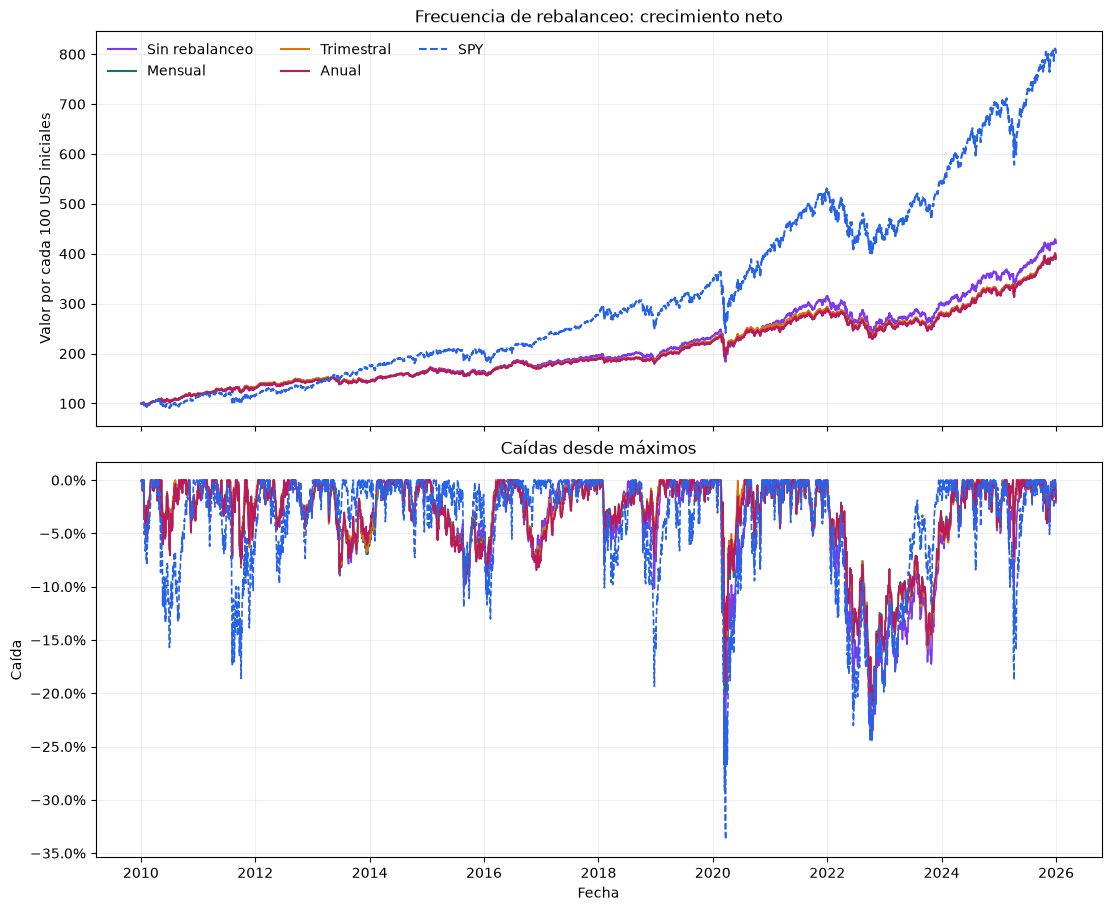

In [13]:
patrimonios_frecuencias = pd.DataFrame({
    nombre: resultado["patrimonio"] for nombre, resultado in comparacion_con_spy.items()
})
colores_frecuencias = {
    "Sin rebalanceo": "#7c3aed", "Mensual": "#0f766e", "Trimestral": "#d97706",
    "Anual": "#be185d", "SPY": "#2563eb",
}
fig, ejes = plt.subplots(2, 1, figsize=(11, 9), sharex=True, layout="constrained")
for nombre, resultado in comparacion_con_spy.items():
    color = colores_frecuencias[nombre]
    estilo = "--" if nombre == "SPY" else "-"
    ejes[0].plot(precios.index, resultado["patrimonio"] / CAPITAL_INICIAL * 100,
                 label=nombre, color=color, ls=estilo, lw=1.5)
    ejes[1].plot(precios.index, resultado["drawdown"], color=color, ls=estilo, lw=1.2)
ejes[0].set(title="Frecuencia de rebalanceo: crecimiento neto", ylabel="Valor por cada 100 USD iniciales")
ejes[0].legend(ncol=3, loc="upper left", frameon=False)
ejes[1].set(title="Caídas desde máximos", ylabel="Caída", xlabel="Fecha")
ejes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in ejes:
    ax.grid(alpha=0.2)
plt.show()

### Actividad de negociación y efecto de los cargos

La muestra contiene **191, 63 y 15 rebalanceos** para las políticas mensual,
trimestral y anual; mantener posiciones no genera rebalanceos. El número de eventos
no informa por sí solo cuánto capital cambió de activo: una operación infrecuente
puede requerir una reasignación mayor.

Por ello se presenta el **volumen relativo anual**, definido como la suma de
$(\mathrm{compras}+\mathrm{ventas})/V_{\mathrm{previo}}$ en cada rebalanceo,
dividida entre los años efectivos. Excluye la entrada y cuenta ambos lados de
la operación. Los costos pagados sí incluyen la compra inicial; su impacto en
el valor final se calcula contra la trayectoria de la misma política a costo cero.

Estas medidas permiten distinguir ahorro de transacciones de ahorro de dinero y
de mejora de rendimiento. Ninguna equivale, por sí sola, a una reducción del riesgo.

In [14]:
anios_comparacion = (precios.index[-1] - precios.index[0]).days / 365.25
filas_costos = {}
for nombre, resultado in resultados_frecuencias.items():
    registro = resultado["operaciones"]
    rebalanceos = registro.loc[registro["Motivo"].str.startswith("Rebalanceo ")]
    bruto = resultados_frecuencias_sin_costos[nombre]
    filas_costos[nombre] = {
        "CAGR sin costos": resumir_backtest(bruto)["CAGR"],
        "CAGR neto": resumen_frecuencias.loc[nombre, "CAGR"],
        "Costos pagados (USD)": resultado["costos"].sum(),
        "Impacto en valor final (USD)": bruto["patrimonio"].iloc[-1] - resultado["patrimonio"].iloc[-1],
        "Volumen relativo anual": rebalanceos["Volumen / patrimonio"].sum() / anios_comparacion,
    }
comparacion_costos = pd.DataFrame(filas_costos).T
display(comparacion_costos.style.format({
    "CAGR sin costos": "{:.2%}", "CAGR neto": "{:.2%}",
    "Costos pagados (USD)": "{:,.2f}", "Impacto en valor final (USD)": "{:,.2f}",
    "Volumen relativo anual": "{:.2%}",
}).set_caption("Efecto de costos y actividad de cada regla"))

,CAGR sin costos,CAGR neto,Costos pagados (USD),Impacto en valor final (USD),Volumen relativo anual
Sin rebalanceo,9.43%,9.42%,9.99,42.18,0.00%
Mensual,8.92%,8.88%,99.56,213.19,27.85%
Trimestral,8.95%,8.92%,63.10,142.76,16.48%
Anual,8.95%,8.93%,34.19,84.04,7.11%


### Deriva de los pesos y concentración final

Sin rebalanceo, SPY pasa del **25.00% inicial al 47.49% final**. Esta concentración
es consistente con su mayor crecimiento relativo y ayuda a interpretar el CAGR
superior de esa política. Mantener posiciones implica aceptar que el perfil de
exposición cambie con la evolución de los activos.

Las políticas periódicas limitan esa deriva mediante restauraciones sucesivas,
pero tampoco terminan necesariamente en 25% por activo: se omite el rebalanceo
en la última fecha. La composición mostrada es la de las posiciones abiertas al
final de la muestra, antes de cualquier liquidación hipotética.

,SPY,IEF,GLD,VNQ
Sin rebalanceo,47.49%,9.13%,21.37%,22.01%
Mensual,25.07%,24.86%,25.59%,24.49%
Trimestral,24.87%,24.45%,27.01%,23.66%
Anual,23.89%,21.93%,33.22%,20.96%


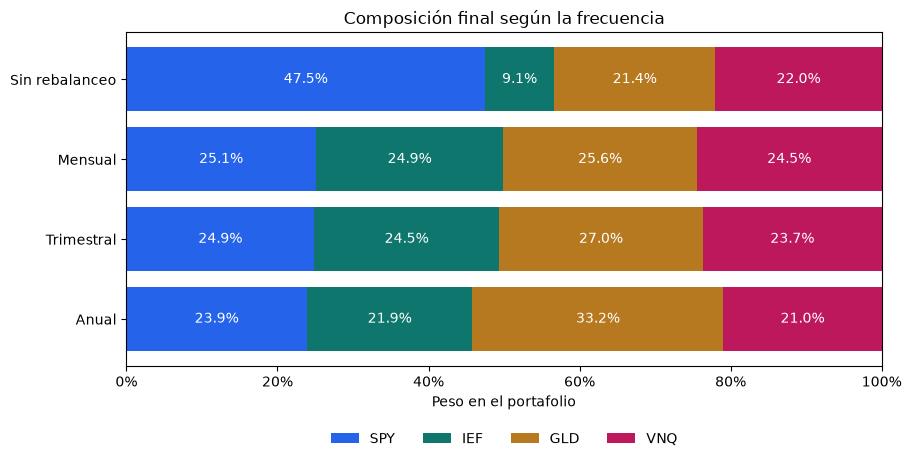

In [15]:
pesos_finales_frecuencias = pd.DataFrame({
    nombre: resultado["pesos"].iloc[-1] for nombre, resultado in resultados_frecuencias.items()
}).T.reindex(columns=precios.columns)
display(pesos_finales_frecuencias.style.format("{:.2%}").set_caption(
    f"Pesos finales al {precios.index[-1]:%Y-%m-%d}"
))
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
izquierda = np.zeros(len(pesos_finales_frecuencias))
colores_activos = {"SPY": "#2563eb", "IEF": "#0f766e", "GLD": "#b7791f", "VNQ": "#be185d"}
for ticker in pesos_finales_frecuencias.columns:
    valores = pesos_finales_frecuencias[ticker].to_numpy()
    ax.barh(pesos_finales_frecuencias.index, valores, left=izquierda,
            color=colores_activos[ticker], label=ticker)
    for fila, (inicio, valor) in enumerate(zip(izquierda, valores)):
        if valor >= 0.06:
            ax.text(inicio + valor / 2, fila, f"{valor:.1%}", ha="center", va="center", color="white")
    izquierda += valores
ax.set(title="Composición final según la frecuencia", xlabel="Peso en el portafolio", xlim=(0, 1))
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.invert_yaxis()
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.16), frameon=False)
plt.show()

### Validación de la comparación

Se comprueban los calendarios de negociación, los pesos posteriores y el balance
de cargos de cada política. Para mantener posiciones se utiliza además una
identidad independiente: el capital invertido multiplicado por la suma ponderada
de los precios normalizados debe reproducir la curva simulada.

La regla mensual coincide con el caso base de la sección 2. Esta comprobación
asegura que las diferencias entre políticas provienen de las reglas evaluadas,
sin introducir un cambio de cálculo entre secciones. SPY sirve como control
adicional de compra y mantenimiento con costo de entrada.

In [16]:
periodos_esperados = {"Mensual": "M", "Trimestral": "Q-DEC", "Anual": "Y-DEC"}
for nombre, resultado in resultados_frecuencias.items():
    registro = resultado["operaciones"]
    fechas_operadas = registro.index[registro["Motivo"].str.startswith("Rebalanceo ")]
    if nombre == "Sin rebalanceo":
        assert len(fechas_operadas) == 0
    else:
        calendario = pd.Series(precios.index, index=precios.index)
        cierres = calendario.groupby(precios.index.to_period(periodos_esperados[nombre])).last()
        esperadas = pd.DatetimeIndex(cierres[(cierres > precios.index[0]) & (cierres < precios.index[-1])])
        assert fechas_operadas.equals(esperadas)
        np.testing.assert_allclose(
            resultado["pesos"].loc[fechas_operadas],
            np.tile(PESOS_OBJETIVO.reindex(precios.columns), (len(fechas_operadas), 1)), atol=1e-12,
        )
    np.testing.assert_allclose(resultado["pesos"].sum(axis=1), 1, atol=1e-12)
    np.testing.assert_allclose(registro["Valor después"] + registro["Costo"], registro["Valor antes"], rtol=1e-12)
    np.testing.assert_allclose(registro["Costo"], registro["Volumen operado"] * COSTO_BPS / 10_000, atol=1e-9)
    np.testing.assert_allclose((1 + resultado["rendimientos"]).prod(), resultado["patrimonio"].iloc[-1] / CAPITAL_INICIAL, rtol=1e-12)
identidad_sin_rebalanceo = (
    CAPITAL_INICIAL / (1 + COSTO_BPS / 10_000)
    * precios.div(precios.iloc[0]).mul(PESOS_OBJETIVO).sum(axis=1)
)
np.testing.assert_allclose(resultados_frecuencias["Sin rebalanceo"]["patrimonio"], identidad_sin_rebalanceo, rtol=1e-12)
mensual_compatible = simular_portafolio(precios, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTO_BPS)
pd.testing.assert_series_equal(resultados_frecuencias["Mensual"]["patrimonio"], mensual_compatible["patrimonio"])
print("Controles correctos: calendarios, pesos, costos y crecimiento acumulado.")
print("Rebalanceos:", {nombre: int(resumen_frecuencias.loc[nombre, "Rebalanceos"]) for nombre in FRECUENCIAS})

Controles correctos: calendarios, pesos, costos y crecimiento acumulado.
Rebalanceos: {'Sin rebalanceo': 0, 'Mensual': 191, 'Trimestral': 63, 'Anual': 15}


### Interpretación de las frecuencias

Entre las cuatro políticas, **sin rebalanceo** lidera el CAGR agregado (**9.42%**),
mientras la política **anual** registra la menor volatilidad (**9.81%**) y la caída
máxima menos profunda (**−21.05%**). La frecuencia con mayor crecimiento no es
la que presenta las mejores medidas de riesgo.

La diferencia de caída entre anual y mensual es pequeña: −21.05% frente a −21.10%.
Esta proximidad no justifica una afirmación fuerte de superioridad económica de
una sobre otra. En cambio, la diferencia en actividad y la concentración final
de la cartera sin rebalanceo sí son relevantes para definir una política de gestión.

El balance histórico favorece evaluar frecuencias menos intensivas cuando el
objetivo admite cierta deriva, pero la muestra completa representa una sola fecha
de entrada. Su estabilidad se examina a continuación por periodos y costos.

In [17]:
solo_portafolios = resumen_frecuencias.loc[list(FRECUENCIAS)]
mayor_cagr = solo_portafolios["CAGR"].idxmax()
menor_vol = solo_portafolios["Volatilidad anualizada"].idxmin()
menor_caida = solo_portafolios["Máxima caída"].idxmax()
print(f"Mayor CAGR observado: {mayor_cagr} ({solo_portafolios.loc[mayor_cagr, 'CAGR']:.2%}).")
print(f"Menor volatilidad: {menor_vol} ({solo_portafolios.loc[menor_vol, 'Volatilidad anualizada']:.2%}).")
print(f"Caída máxima menos profunda: {menor_caida} ({solo_portafolios.loc[menor_caida, 'Máxima caída']:.2%}).")
peso_spy_final = pesos_finales_frecuencias.loc["Sin rebalanceo", "SPY"]
print(f"SPY sin rebalanceo: peso inicial {PESOS_OBJETIVO['SPY']:.2%}; peso final {peso_spy_final:.2%}.")

Mayor CAGR observado: Sin rebalanceo (9.42%).
Menor volatilidad: Anual (9.81%).
Caída máxima menos profunda: Anual (-21.05%).
SPY sin rebalanceo: peso inicial 25.00%; peso final 47.49%.


### Alcance del resultado agregado

La comparación 2010–2025 demuestra que restaurar pesos con mayor frecuencia
no asegura mayor crecimiento ni menor caída. La decisión depende del grado de
desviación aceptable, de la actividad que genera y del periodo observado. Las
políticas anuales y trimestrales conservan interés analítico aunque ninguna
encabece todas las métricas.

La evaluación de robustez conserva estas reglas y modifica periodo y costo.
Ese diseño permite comprobar si el orden observado se mantiene bajo condiciones
alternativas, sin ajustar los pesos para mejorar retrospectivamente el resultado.

## 4. Robustez por subperiodos y sensibilidad a los costos

El experimento cruza **cinco periodos, seis niveles de costo y cinco estrategias**,
para un total de **150 escenarios**. Los periodos son la muestra completa y cuatro
bloques calendario de cuatro años: 2010–2013, 2014–2017, 2018–2021 y 2022–2025.
Se comparan las cuatro políticas del portafolio y SPY, bajo cargos de **0, 5, 10,
25, 50 y 100 pb** por importe comprado o vendido.

Cada bloque reinicia capital y pesos al primer cierre disponible y paga su propia
entrada. No hereda posiciones ni incorpora el rendimiento entre el último cierre
del bloque anterior y el primero del siguiente. Por tanto, los bloques son
experimentos separados y no se encadenan para reconstruir la trayectoria completa.
Se mantiene la ausencia de liquidación y de rebalanceo en la fecha terminal.

Los bloques son intervalos regulares, sin identificarlos mediante un modelo de
regímenes económicos. Los costos son supuestos de sensibilidad, no tarifas
observadas. Aunque los bloques no se solapan, todo el historial ya forma parte
del estudio: el ejercicio evalúa estabilidad dentro de la muestra y no constituye
validación fuera de muestra. Los escenarios que comparten precios tampoco son
observaciones estadísticas independientes.

In [18]:
SUBPERIODOS = {
    "2010–2013": ("2010-01-01", "2013-12-31"),
    "2014–2017": ("2014-01-01", "2017-12-31"),
    "2018–2021": ("2018-01-01", "2021-12-31"),
    "2022–2025": ("2022-01-01", "2025-12-31"),
}
COSTOS_PRUEBA_BPS = sorted(set([0.0, 5.0, 10.0, 25.0, 50.0, 100.0, float(COSTO_BPS)]))
PERIODOS_INVESTIGACION = {
    "Muestra completa": (precios.index[0].strftime("%Y-%m-%d"), precios.index[-1].strftime("%Y-%m-%d")),
    **SUBPERIODOS,
}

In [19]:
# Investigación de robustez: escenarios independientes.
def investigar_escenarios(precios, pesos, capital_inicial, costos_bps, periodos, frecuencias):
    '''Reinicia cada estrategia por periodo y costo; devuelve métricas en formato largo.'''
    if "SPY" not in precios.columns:
        raise ValueError("Se requiere SPY para la referencia.")
    if not periodos or not frecuencias or "SPY" in frecuencias:
        raise ValueError("Define periodos y frecuencias; SPY está reservado para la referencia.")
    costos = np.asarray(list(costos_bps), dtype=float)
    if costos.ndim != 1 or costos.size == 0 or not np.isfinite(costos).all():
        raise ValueError("Los costos deben ser una lista no vacía de valores finitos.")
    if (costos < 0).any() or (costos >= 10_000).any():
        raise ValueError("Los costos deben estar en [0, 10,000) puntos base.")
    costos = sorted(set([0.0, *costos.tolist()]))
    ventanas = {}
    for nombre, (inicio, fin) in periodos.items():
        inicio, fin = pd.Timestamp(inicio), pd.Timestamp(fin)
        if pd.isna(inicio) or pd.isna(fin) or inicio > fin:
            raise ValueError(f"Intervalo inválido: {nombre}.")
        ventana = precios.loc[inicio:fin]
        if len(ventana) < 3:
            raise ValueError(f"{nombre}: se requieren al menos tres observaciones.")
        ventanas[nombre] = ventana

    filas = []
    reglas = {**frecuencias, "SPY": "sin rebalanceo"}
    for periodo, ventana in ventanas.items():
        anios = (ventana.index[-1] - ventana.index[0]).days / 365.25
        for costo in costos:
            for estrategia, frecuencia in reglas.items():
                datos = ventana[["SPY"]] if estrategia == "SPY" else ventana
                asignacion = {"SPY": 1.0} if estrategia == "SPY" else pesos
                resultado = simular_portafolio(
                    datos, asignacion, capital_inicial, costo, frecuencia=frecuencia
                )
                registro = resultado["operaciones"]
                rb = registro.loc[registro["Motivo"].str.startswith("Rebalanceo ")]
                # Controles por escenario: entrada, autofinanciación y pesos posteriores.
                np.testing.assert_allclose(resultado["patrimonio"].iloc[0], capital_inicial / (1 + costo / 10_000))
                np.testing.assert_allclose(resultado["pesos"].iloc[0], pd.Series(asignacion).reindex(datos.columns), atol=1e-12)
                np.testing.assert_allclose(registro["Valor después"] + registro["Costo"], registro["Valor antes"], rtol=1e-12)
                np.testing.assert_allclose(registro["Costo"], registro["Volumen operado"] * costo / 10_000, atol=1e-8)
                np.testing.assert_allclose(resultado["pesos"].sum(axis=1), 1.0, atol=1e-12)
                if len(rb):
                    np.testing.assert_allclose(
                        resultado["pesos"].loc[rb.index],
                        np.tile(pd.Series(asignacion).reindex(datos.columns), (len(rb), 1)), atol=1e-12,
                    )
                if frecuencia == "sin rebalanceo":
                    identidad = capital_inicial / (1 + costo / 10_000) * datos.div(datos.iloc[0]).mul(pd.Series(asignacion)).sum(axis=1)
                    np.testing.assert_allclose(resultado["patrimonio"], identidad, rtol=1e-12)
                filas.append({
                    "Periodo": periodo, "Costo (pb)": costo, "Estrategia": estrategia,
                    "Inicio real": ventana.index[0], "Fin real": ventana.index[-1],
                    "Observaciones": len(ventana), **resumir_backtest(resultado).to_dict(),
                    "Volumen relativo anual": rb["Volumen / patrimonio"].sum() / anios,
                })
    tabla = pd.DataFrame(filas).set_index(["Periodo", "Costo (pb)", "Estrategia"])
    sin_costos = tabla.xs(0.0, level="Costo (pb)")["Valor final (USD)"]
    tabla["Impacto en valor final (USD)"] = [
        sin_costos.loc[(periodo, estrategia)] - fila["Valor final (USD)"]
        for (periodo, costo, estrategia), fila in tabla.iterrows()
    ]
    tabla["Rebalanceos"] = tabla["Rebalanceos"].astype(int)
    return tabla

In [20]:
# Siempre conservar el control sin costos y la tasa activa al editar la cuadrícula.
COSTOS_PRUEBA_BPS = sorted(set([0.0, float(COSTO_BPS), *map(float, COSTOS_PRUEBA_BPS)]))
escenarios_robustez = investigar_escenarios(
    precios, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTOS_PRUEBA_BPS,
    PERIODOS_INVESTIGACION, FRECUENCIAS,
)
print(f"{len(escenarios_robustez)} escenarios: {len(PERIODOS_INVESTIGACION)} periodos × "
      f"{len(COSTOS_PRUEBA_BPS)} costos × {len(FRECUENCIAS) + 1} estrategias.")
cobertura_robustez = escenarios_robustez.reset_index().groupby("Periodo", sort=False)[
    ["Inicio real", "Fin real", "Observaciones"]
].first()
display(cobertura_robustez.style.format({
    "Inicio real": lambda fecha: fecha.strftime("%Y-%m-%d"),
    "Fin real": lambda fecha: fecha.strftime("%Y-%m-%d"), "Observaciones": "{:,.0f}",
}).set_caption("Cobertura efectiva: verificar estas fechas si se cambian los intervalos"))

150 escenarios: 5 periodos × 6 costos × 5 estrategias.


,Inicio real,Fin real,Observaciones
Periodo,,,
Muestra completa,2010-01-04,2025-12-31,"4,024"
2010–2013,2010-01-04,2013-12-31,"1,006"
2014–2017,2014-01-02,2017-12-29,"1,007"
2018–2021,2018-01-02,2021-12-31,"1,008"
2022–2025,2022-01-03,2025-12-31,"1,003"


### Resultados por subperiodo al costo base

Con **10 pb**, el mayor CAGR entre las cuatro políticas corresponde al rebalanceo
**trimestral en 2010–2013 y 2018–2021**, y a **mantener posiciones en 2014–2017 y
2022–2025**. La política anual registra la menor volatilidad en tres bloques;
la mensual lo hace en 2014–2017. El liderazgo cambia tanto con el periodo como
con la métrica utilizada.

El CAGR se anualiza con la duración efectiva de cada inversión y la volatilidad
con 252 sesiones. Las caídas se calculan desde los máximos de la inversión
reiniciada, incorporando el capital previo a la entrada. Esta definición explica
por qué el drawdown de un bloque puede diferir del que experimenta durante esas
fechas una posición mantenida desde 2010.

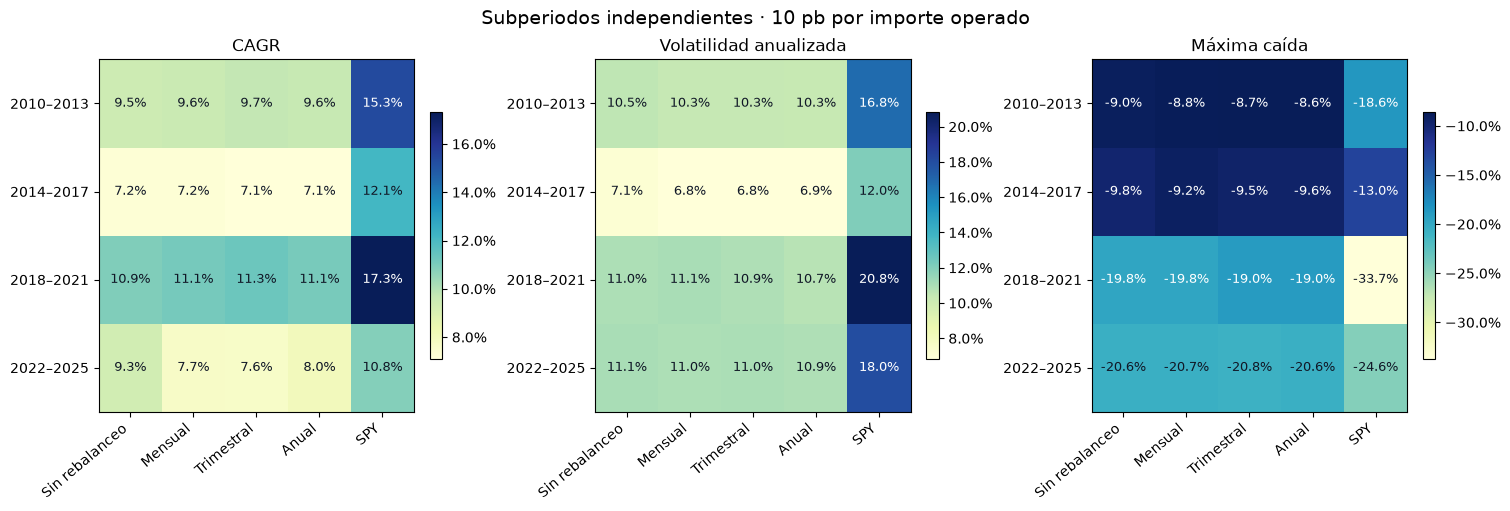

In [21]:
orden_estrategias = [*FRECUENCIAS, "SPY"]
orden_subperiodos = list(SUBPERIODOS)
base_subperiodos = escenarios_robustez.xs(float(COSTO_BPS), level="Costo (pb)").loc[
    pd.MultiIndex.from_product([orden_subperiodos, orden_estrategias], names=["Periodo", "Estrategia"])
]
metricas_periodos = ["CAGR", "Volatilidad anualizada", "Máxima caída"]
display(base_subperiodos[metricas_periodos].style.format("{:.2%}").set_caption(
    f"Métricas netas por bloque independiente · costo {COSTO_BPS:g} pb"
))

fig, ejes = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")
for ax, metrica in zip(ejes, metricas_periodos):
    matriz = base_subperiodos[metrica].unstack("Estrategia").reindex(index=orden_subperiodos, columns=orden_estrategias)
    valores = matriz.to_numpy()
    mapa = ax.imshow(valores, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(len(orden_estrategias)), labels=orden_estrategias, rotation=40, ha="right")
    ax.set_yticks(range(len(orden_subperiodos)), labels=orden_subperiodos)
    ax.set_title(metrica)
    for fila in range(valores.shape[0]):
        for columna in range(valores.shape[1]):
            valor = valores[fila, columna]
            ax.text(columna, fila, f"{valor:.1%}", ha="center", va="center",
                    color="white" if mapa.norm(valor) > 0.55 else "#111827", fontsize=9)
    barra = fig.colorbar(mapa, ax=ax, shrink=0.7)
    barra.ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.suptitle(f"Subperiodos independientes · {COSTO_BPS:g} pb por importe operado", fontsize=14)
plt.show()

### Sensibilidad de la muestra completa a los cargos

Cada nivel de costo vuelve a simular toda la trayectoria. Frente a costo cero,
un cargo de **100 pb** reduce el CAGR mensual en **0.371 puntos porcentuales
anuales**, el trimestral en **0.247 pp** y el anual en **0.145 pp**. Mantener
posiciones pierde **0.068 pp**, debido únicamente a su compra inicial.

La mayor sensibilidad de la política mensual confirma la relevancia de la
actividad acumulada. El efecto sobre riqueza final incluye los cargos y la
capitalización perdida, por lo que no se obtiene restando simplemente la suma
nominal de comisiones a la trayectoria sin costos.

Las gráficas muestran CAGR neto y su pérdida frente a costo cero. Los niveles
altos son escenarios ilustrativos; no modelan por separado spread, liquidez,
impacto de mercado ni impuestos. Una menor sensibilidad al cargo no implica
un riesgo de mercado menor.

Estrategia,Sin rebalanceo,Mensual,Trimestral,Anual,SPY
Costo (pb),,,,,
0.000000,9.43%,8.92%,8.95%,8.95%,13.91%
5.000000,9.42%,8.90%,8.93%,8.94%,13.90%
10.000000,9.42%,8.88%,8.92%,8.93%,13.90%
25.000000,9.41%,8.83%,8.88%,8.91%,13.89%
50.000000,9.39%,8.73%,8.82%,8.88%,13.87%
100.000000,9.36%,8.55%,8.70%,8.80%,13.84%


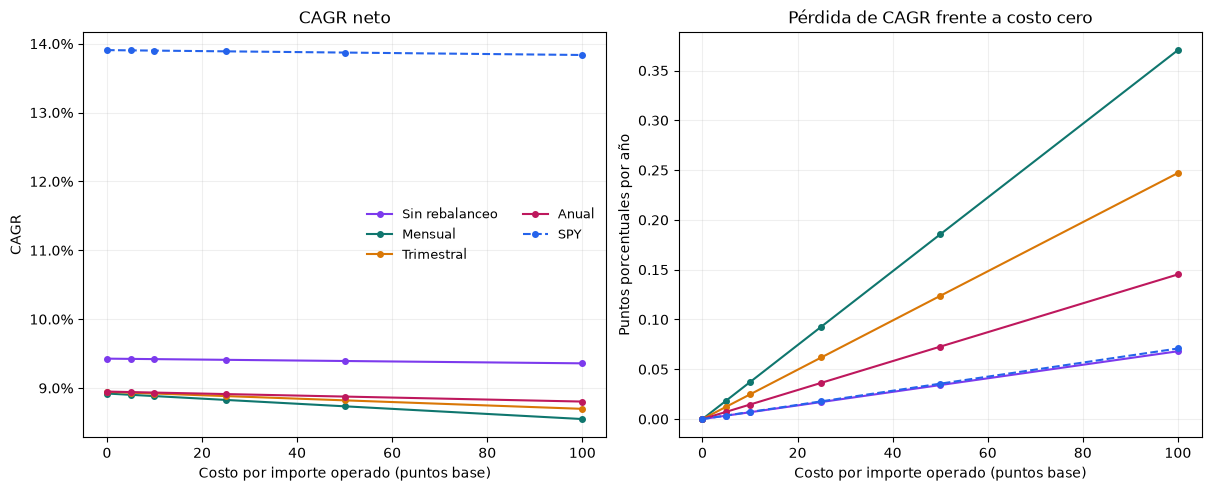

,Costos pagados (USD),Impacto en valor final (USD)
Estrategia,,
Sin rebalanceo,99.01,418.05
Mensual,965.88,"2,078.97"
Trimestral,618.05,"1,402.99"
Anual,337.43,830.79
SPY,99.01,794.05


In [22]:
muestra_costos = escenarios_robustez.xs("Muestra completa", level="Periodo")
cagr_por_costo = muestra_costos["CAGR"].unstack("Estrategia").reindex(index=COSTOS_PRUEBA_BPS, columns=orden_estrategias)
perdida_cagr_pp = (cagr_por_costo.loc[0.0] - cagr_por_costo) * 100
display(cagr_por_costo.style.format("{:.2%}").set_caption("CAGR neto por costo · muestra completa"))

colores_robustez = {"Sin rebalanceo": "#7c3aed", "Mensual": "#0f766e", "Trimestral": "#d97706", "Anual": "#be185d", "SPY": "#2563eb"}
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
for estrategia in orden_estrategias:
    estilo = "--" if estrategia == "SPY" else "-"
    ejes[0].plot(cagr_por_costo.index, cagr_por_costo[estrategia], marker="o", ms=4,
                 color=colores_robustez[estrategia], ls=estilo, label=estrategia)
    ejes[1].plot(perdida_cagr_pp.index, perdida_cagr_pp[estrategia], marker="o", ms=4,
                 color=colores_robustez[estrategia], ls=estilo, label=estrategia)
ejes[0].set(title="CAGR neto", ylabel="CAGR")
ejes[0].yaxis.set_major_formatter(PercentFormatter(1))
ejes[1].set(title="Pérdida de CAGR frente a costo cero", ylabel="Puntos porcentuales por año")
for ax in ejes:
    ax.set_xlabel("Costo por importe operado (puntos base)")
    ax.grid(alpha=0.2)
ejes[0].legend(ncol=2, frameon=False, fontsize=9)
plt.show()

costo_alto = max(COSTOS_PRUEBA_BPS)
detalle_costo_alto = muestra_costos.xs(costo_alto, level="Costo (pb)").reindex(orden_estrategias)[
    ["Costos pagados (USD)", "Impacto en valor final (USD)"]
]
display(detalle_costo_alto.style.format("{:,.2f}").set_caption(
    f"Cargos nominales e impacto acumulado en patrimonio · escenario {costo_alto:g} pb"
))

### Cambios de liderazgo entre periodo y costo

La matriz identifica el mayor CAGR entre los cuatro portafolios; SPY permanece
como referencia en las comparaciones de desempeño. El líder cambia a lo largo
de la cuadrícula de costos en **2010–2013 y 2014–2017**, mientras los otros dos
bloques conservan su líder en los niveles evaluados. En 2010–2013, trimestral
lidera entre 0 y 50 pb y anual a 100 pb; en 2014–2017, mensual lidera a costo
cero y mantener posiciones en todos los niveles positivos de la cuadrícula.

La lectura debe limitarse a los puntos simulados. No se interpola un costo
preciso de cruce ni se estima una frecuencia óptima. Las diferencias numéricas
inferiores a $10^{-10}$ se registran como empate. El liderazgo por CAGR describe
crecimiento y no incorpora una preferencia por menor volatilidad, menor caída
o mayor estabilidad de los pesos.

In [23]:
def nombres_extremos(serie, maximizar=True):
    extremo = serie.max() if maximizar else serie.min()
    return " / ".join(serie.index[np.isclose(serie.to_numpy(), extremo, rtol=0, atol=1e-10)])

lideres_cagr = pd.DataFrame(index=orden_subperiodos, columns=COSTOS_PRUEBA_BPS, dtype=object)
for periodo in orden_subperiodos:
    for costo in COSTOS_PRUEBA_BPS:
        valores = escenarios_robustez.xs((periodo, costo), level=["Periodo", "Costo (pb)"])["CAGR"].reindex(list(FRECUENCIAS))
        lideres_cagr.loc[periodo, costo] = nombres_extremos(valores)
lideres_cagr.index.name = "Periodo"
lideres_cagr.columns.name = "Costo (pb)"
display(lideres_cagr.style.set_caption("Mayor CAGR por periodo y costo; empates separados por /"))

extremos_por_periodo = pd.DataFrame(index=orden_subperiodos)
for periodo in orden_subperiodos:
    metricas = base_subperiodos.loc[periodo].reindex(list(FRECUENCIAS))
    extremos_por_periodo.loc[periodo, "Mayor CAGR"] = nombres_extremos(metricas["CAGR"])
    extremos_por_periodo.loc[periodo, "Menor volatilidad"] = nombres_extremos(metricas["Volatilidad anualizada"], False)
    extremos_por_periodo.loc[periodo, "Caída menos profunda"] = nombres_extremos(metricas["Máxima caída"])
display(extremos_por_periodo.style.set_caption(f"Tres criterios distintos · costo activo {COSTO_BPS:g} pb"))

Costo (pb),0.000000,5.000000,10.000000,25.000000,50.000000,100.000000
Periodo,,,,,,
2010–2013,Trimestral,Trimestral,Trimestral,Trimestral,Trimestral,Anual
2014–2017,Mensual,Sin rebalanceo,Sin rebalanceo,Sin rebalanceo,Sin rebalanceo,Sin rebalanceo
2018–2021,Trimestral,Trimestral,Trimestral,Trimestral,Trimestral,Trimestral
2022–2025,Sin rebalanceo,Sin rebalanceo,Sin rebalanceo,Sin rebalanceo,Sin rebalanceo,Sin rebalanceo


,Mayor CAGR,Menor volatilidad,Caída menos profunda
2010–2013,Trimestral,Anual,Anual
2014–2017,Sin rebalanceo,Mensual,Mensual
2018–2021,Trimestral,Anual,Trimestral / Anual
2022–2025,Sin rebalanceo,Anual,Sin rebalanceo / Anual


### Controles de consistencia de los escenarios

Los 150 escenarios verifican entrada, objetivos de pesos y autofinanciación.
La muestra completa a 10 pb reproduce los resultados de la sección 3; aumentar
el costo no incrementa el valor final ni el CAGR, y no altera las fechas de
las políticas basadas en calendario.

No se exige que los cargos nominales aumenten siempre con la tasa. Un costo
mayor también reduce el patrimonio sobre el que se negocia. La comprobación
económica pertinente es que el incremento del cargo no cree riqueza en una
trayectoria con las mismas reglas y precios.

In [24]:
esperado = len(PERIODOS_INVESTIGACION) * len(COSTOS_PRUEBA_BPS) * len(orden_estrategias)
assert len(escenarios_robustez) == esperado and escenarios_robustez.index.is_unique
columnas_numericas = ["Valor final (USD)", "CAGR", "Volatilidad anualizada", "Máxima caída", "Costos pagados (USD)"]
assert np.isfinite(escenarios_robustez[columnas_numericas].to_numpy()).all()
for (_, _), grupo in escenarios_robustez.groupby(level=["Periodo", "Estrategia"], sort=False):
    grupo = grupo.reset_index().sort_values("Costo (pb)")
    assert (grupo["Valor final (USD)"].diff().dropna() <= 1e-8).all()
    assert (grupo["CAGR"].diff().dropna() <= 1e-12).all()
    assert grupo["Rebalanceos"].nunique() == 1
np.testing.assert_allclose(escenarios_robustez.xs(0.0, level="Costo (pb)")["Costos pagados (USD)"], 0, atol=1e-9)
base_completa = muestra_costos.xs(float(COSTO_BPS), level="Costo (pb)").reindex(orden_estrategias)
np.testing.assert_allclose(base_completa[resumen_frecuencias.columns], resumen_frecuencias.reindex(orden_estrategias), rtol=1e-12, atol=1e-9)
print(f"Controles correctos para {esperado} escenarios.")
for periodo in orden_subperiodos:
    print(f"{periodo}: mayor CAGR = {extremos_por_periodo.loc[periodo, 'Mayor CAGR']}; "
          f"menor volatilidad = {extremos_por_periodo.loc[periodo, 'Menor volatilidad']}; "
          f"caída menos profunda = {extremos_por_periodo.loc[periodo, 'Caída menos profunda']}.")
lider_global = nombres_extremos(base_completa.loc[list(FRECUENCIAS), "CAGR"])
print(f"Muestra completa al costo activo: mayor CAGR = {lider_global}.")
cambios = [periodo for periodo in orden_subperiodos if lideres_cagr.loc[periodo].nunique() > 1]
print("Periodos donde cambia el líder por CAGR en la cuadrícula de costos: " + (", ".join(cambios) if cambios else "ninguno") + ".")
print(f"Pérdida de CAGR a {costo_alto:g} pb frente a cero (puntos porcentuales anuales):")
for estrategia, valor in perdida_cagr_pp.loc[costo_alto].items():
    print(f"  {estrategia}: {valor:.3f} pp.")

Controles correctos para 150 escenarios.
2010–2013: mayor CAGR = Trimestral; menor volatilidad = Anual; caída menos profunda = Anual.
2014–2017: mayor CAGR = Sin rebalanceo; menor volatilidad = Mensual; caída menos profunda = Mensual.
2018–2021: mayor CAGR = Trimestral; menor volatilidad = Anual; caída menos profunda = Trimestral / Anual.
2022–2025: mayor CAGR = Sin rebalanceo; menor volatilidad = Anual; caída menos profunda = Sin rebalanceo / Anual.
Muestra completa al costo activo: mayor CAGR = Sin rebalanceo.
Periodos donde cambia el líder por CAGR en la cuadrícula de costos: 2010–2013, 2014–2017.
Pérdida de CAGR a 100 pb frente a cero (puntos porcentuales anuales):
  Sin rebalanceo: 0.068 pp.
  Mensual: 0.371 pp.
  Trimestral: 0.247 pp.
  Anual: 0.145 pp.
  SPY: 0.071 pp.


### Conclusión de la sensibilidad por bloques y costos

La clasificación agregada depende del periodo y, en algunos bloques, del cargo
aplicado. El mayor CAGR de mantener posiciones en 2010–2025 no se reproduce en
todos los subperiodos, y la política mensual concentra la mayor pérdida de CAGR
al elevar el costo. Ambas observaciones favorecen analizar exposición y actividad
junto con crecimiento, antes de fijar una política.

La ausencia de un líder uniforme es un resultado del estudio. Cuatro bloques
permiten detectar variación, pero no describen todas las fechas posibles de entrada.
La sección 5 amplía esa observación con ventanas móviles de duración comparable.

`escenarios_robustez` conserva las métricas y la cobertura efectiva. Al modificar
`SUBPERIODOS` o `COSTOS_PRUEBA_BPS`, deben revisarse las fechas disponibles y
actualizarse las conclusiones; la cuadrícula incluye automáticamente costo cero
y el costo base activo.

## 5. Ventanas móviles: sensibilidad a la fecha de entrada

Se evalúan **145 ventanas nominales de 48 meses**, con inicios separados un mes,
desde el 04/01/2010 hasta el 03/01/2022. Las cuatro políticas y SPY generan
**725 simulaciones**. Cada ventana reinicia capital y pesos, paga entrada y utiliza
el cargo base de 10 pb, sin heredar posiciones de la ventana anterior.

La entrada corresponde al primer cierre disponible del mes y la salida al último
del mes número 48. El CAGR usa los días efectivos entre ambos cierres. Los
rebalanceos trimestrales y anuales siguen el calendario, no los aniversarios de
entrada, y se omite el rebalanceo en la última fecha de cada inversión.

Se exige que estén representados todos los meses y que el final calendario de
la ventana quede cubierto por el CSV. Esta regla conservadora puede excluir un
mes cuyo último día calendario sea posterior al último precio disponible; no
afecta al corte actual del 31/12/2025. La presencia de cada mes no demuestra
por sí sola que estén todas las sesiones bursátiles intermedias.

El solapamiento es amplio: ventanas contiguas comparten casi todo su historial.
Sus medianas, rangos y cuotas son descripciones de sensibilidad a la entrada,
no estimaciones de probabilidades futuras ni observaciones independientes.

In [25]:
MESES_VENTANA = 48
PASO_MESES = 1

In [26]:
# Ventanas móviles: generación y evaluación.
def construir_ventanas_mensuales(precios, meses=48, paso_meses=1):
    '''Construye ventanas nominales, con fin calendario cubierto y sin meses ausentes.'''
    for nombre, valor in [("meses", meses), ("paso_meses", paso_meses)]:
        if isinstance(valor, (bool, np.bool_)) or not isinstance(valor, (int, np.integer)) or valor <= 0:
            raise ValueError(f"{nombre} debe ser un entero positivo.")
    indice = precios.index
    if not isinstance(indice, pd.DatetimeIndex) or indice.hasnans or len(indice) < 3:
        raise ValueError("Se requieren al menos tres fechas válidas.")
    if not indice.is_unique or not indice.is_monotonic_increasing:
        raise ValueError("Las fechas deben ser únicas y estar ordenadas.")
    presentes = set(indice.to_period("M"))
    primero, ultimo = indice[0].to_period("M"), indice[-1].to_period("M")
    filas = []
    for desplazamiento in range(0, ultimo.ordinal - primero.ordinal + 1, paso_meses):
        inicio_mes = primero + desplazamiento
        fin_mes = inicio_mes + meses - 1
        inicio = inicio_mes.start_time
        fin = fin_mes.end_time.normalize()
        if fin > indice[-1].normalize():
            break
        esperados = set(pd.period_range(inicio_mes, fin_mes, freq="M"))
        if not esperados.issubset(presentes):
            continue
        bloque = precios.loc[inicio:fin]
        if len(bloque) < 3:
            continue
        filas.append({
            "Ventana": str(inicio_mes), "Inicio solicitado": inicio, "Fin solicitado": fin,
            "Inicio real": bloque.index[0], "Fin real": bloque.index[-1],
            "Observaciones": len(bloque),
            "Años efectivos": (bloque.index[-1] - bloque.index[0]).days / 365.25,
        })
    if not filas:
        raise ValueError("No hay ventanas completas con el horizonte y cobertura indicados.")
    return pd.DataFrame(filas).set_index("Ventana")


def evaluar_ventanas_moviles(precios, pesos, capital_inicial, costo_bps, ventanas, frecuencias):
    '''Evalúa cada ventana reiniciando posiciones; SPY se añade como referencia.'''
    if "SPY" not in precios.columns or not frecuencias or "SPY" in frecuencias:
        raise ValueError("Se requiere SPY en precios y frecuencias válidas; el nombre SPY está reservado.")
    columnas = {"Inicio solicitado", "Fin solicitado", "Inicio real", "Fin real", "Observaciones", "Años efectivos"}
    if ventanas.empty or not ventanas.index.is_unique or not columnas.issubset(ventanas.columns):
        raise ValueError("Regenera la tabla de ventanas: está vacía, duplicada o incompleta.")
    bloques = {}
    for etiqueta, datos_ventana in ventanas.iterrows():
        inicio = pd.Timestamp(datos_ventana["Inicio solicitado"])
        fin = pd.Timestamp(datos_ventana["Fin solicitado"])
        if pd.isna(inicio) or pd.isna(fin) or inicio > fin or fin > precios.index[-1].normalize():
            raise ValueError(f"Límites inválidos en {etiqueta}; regenera las ventanas.")
        bloque = precios.loc[inicio:fin]
        if (len(bloque) < 3 or len(bloque) != datos_ventana["Observaciones"]
                or bloque.index[0] != datos_ventana["Inicio real"]
                or bloque.index[-1] != datos_ventana["Fin real"]):
            raise ValueError(f"La cobertura cambió en {etiqueta}; regenera las ventanas.")
        anios = (bloque.index[-1] - bloque.index[0]).days / 365.25
        if not np.isclose(anios, datos_ventana["Años efectivos"], rtol=0, atol=1e-12):
            raise ValueError(f"Duración incoherente en {etiqueta}; regenera las ventanas.")
        bloques[etiqueta] = bloque

    reglas = {**frecuencias, "SPY": "sin rebalanceo"}
    filas = []
    for etiqueta, bloque in bloques.items():
        for nombre, frecuencia in reglas.items():
            datos = bloque[["SPY"]] if nombre == "SPY" else bloque
            asignacion = {"SPY": 1.0} if nombre == "SPY" else pesos
            resultado = simular_portafolio(datos, asignacion, capital_inicial, costo_bps, frecuencia=frecuencia)
            entrada = capital_inicial / (1 + costo_bps / 10_000)
            np.testing.assert_allclose(resultado["patrimonio"].iloc[0], entrada, rtol=1e-12)
            np.testing.assert_allclose(resultado["pesos"].iloc[0], pd.Series(asignacion).reindex(datos.columns), atol=1e-12)
            if frecuencia == "sin rebalanceo":
                identidad = entrada * datos.div(datos.iloc[0]).mul(pd.Series(asignacion)).sum(axis=1)
                np.testing.assert_allclose(resultado["patrimonio"], identidad, rtol=1e-12)
            registro = resultado["operaciones"]
            np.testing.assert_allclose(registro["Valor después"] + registro["Costo"], registro["Valor antes"], rtol=1e-12)
            np.testing.assert_allclose(registro["Costo"], registro["Volumen operado"] * costo_bps / 10_000, atol=1e-8)
            filas.append({
                "Ventana": etiqueta, "Estrategia": nombre,
                **ventanas.loc[etiqueta].to_dict(), **resumir_backtest(resultado).to_dict(),
            })
    tabla = pd.DataFrame(filas).set_index(["Ventana", "Estrategia"])
    tabla["Rebalanceos"] = tabla["Rebalanceos"].astype(int)
    return tabla


def cuotas_liderazgo(matriz, maximizar=True):
    '''Cuotas descriptivas; un empate entre k estrategias aporta 1/k a cada una.'''
    if matriz.empty or not np.isfinite(matriz.to_numpy(dtype=float)).all():
        raise ValueError("La matriz debe contener métricas finitas.")
    extremos = matriz.max(axis=1) if maximizar else matriz.min(axis=1)
    lider = pd.DataFrame(np.isclose(matriz.to_numpy(), extremos.to_numpy()[:, None], rtol=0, atol=1e-10),
                         index=matriz.index, columns=matriz.columns)
    numero_lideres = lider.sum(axis=1)
    return pd.DataFrame({
        "Liderazgos exclusivos": lider.loc[numero_lideres == 1].sum(axis=0),
        "Liderazgos compartidos": lider.loc[numero_lideres > 1].sum(axis=0),
        "Cuota descriptiva": lider.div(numero_lideres, axis=0).sum(axis=0) / len(matriz),
    })

In [27]:
ventanas_moviles = construir_ventanas_mensuales(precios, MESES_VENTANA, PASO_MESES)
resultados_moviles = evaluar_ventanas_moviles(
    precios, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTO_BPS, ventanas_moviles, FRECUENCIAS,
)
estrategias_moviles = [*FRECUENCIAS, "SPY"]
print(f"{len(ventanas_moviles)} ventanas × {len(estrategias_moviles)} estrategias = {len(resultados_moviles)} simulaciones.")
print(f"Horizonte: {MESES_VENTANA} meses | Avance: {PASO_MESES} mes(es) | Costo: {COSTO_BPS:g} pb.")
print(f"Primera entrada: {ventanas_moviles['Inicio real'].iloc[0]:%Y-%m-%d}; "
      f"última entrada: {ventanas_moviles['Inicio real'].iloc[-1]:%Y-%m-%d}.")
vista_ventanas = pd.concat([ventanas_moviles.head(2), ventanas_moviles.tail(2)])
vista_ventanas = vista_ventanas.loc[~vista_ventanas.index.duplicated()]
display(vista_ventanas.style.format({
    **{col: lambda fecha: fecha.strftime("%Y-%m-%d") for col in ["Inicio solicitado", "Fin solicitado", "Inicio real", "Fin real"]},
    "Observaciones": "{:,.0f}", "Años efectivos": "{:.3f}",
}).set_caption("Primeras y últimas ventanas; tabla completa disponible en ventanas_moviles"))

145 ventanas × 5 estrategias = 725 simulaciones.
Horizonte: 48 meses | Avance: 1 mes(es) | Costo: 10 pb.
Primera entrada: 2010-01-04; última entrada: 2022-01-03.


,Inicio solicitado,Fin solicitado,Inicio real,Fin real,Observaciones,Años efectivos
Ventana,,,,,,
2010-01,2010-01-01,2013-12-31,2010-01-04,2013-12-31,"1,006",3.989
2010-02,2010-02-01,2014-01-31,2010-02-01,2014-01-31,"1,008",3.997
2021-12,2021-12-01,2025-11-30,2021-12-01,2025-11-28,"1,003",3.992
2022-01,2022-01-01,2025-12-31,2022-01-03,2025-12-31,"1,003",3.992


### Desempeño condicionado al mes de entrada

Cada punto representa el resultado de una inversión de 48 meses identificada
por su fecha inicial. Las curvas comparan experiencias de inversión alternativas;
**no representan una trayectoria continua de patrimonio**. La volatilidad y la
caída máxima se calculan dentro de cada ventana.

La variación de las curvas muestra que una regla puede comportarse de forma
distinta según la fecha de entrada, aunque sus instrucciones permanezcan fijas.
Esta dimensión queda oculta al resumir los 16 años mediante un único CAGR.
Las separaciones entre políticas se interpretan sobre ventanas con fechas
coincidentes, manteniendo constantes capital inicial y costos.

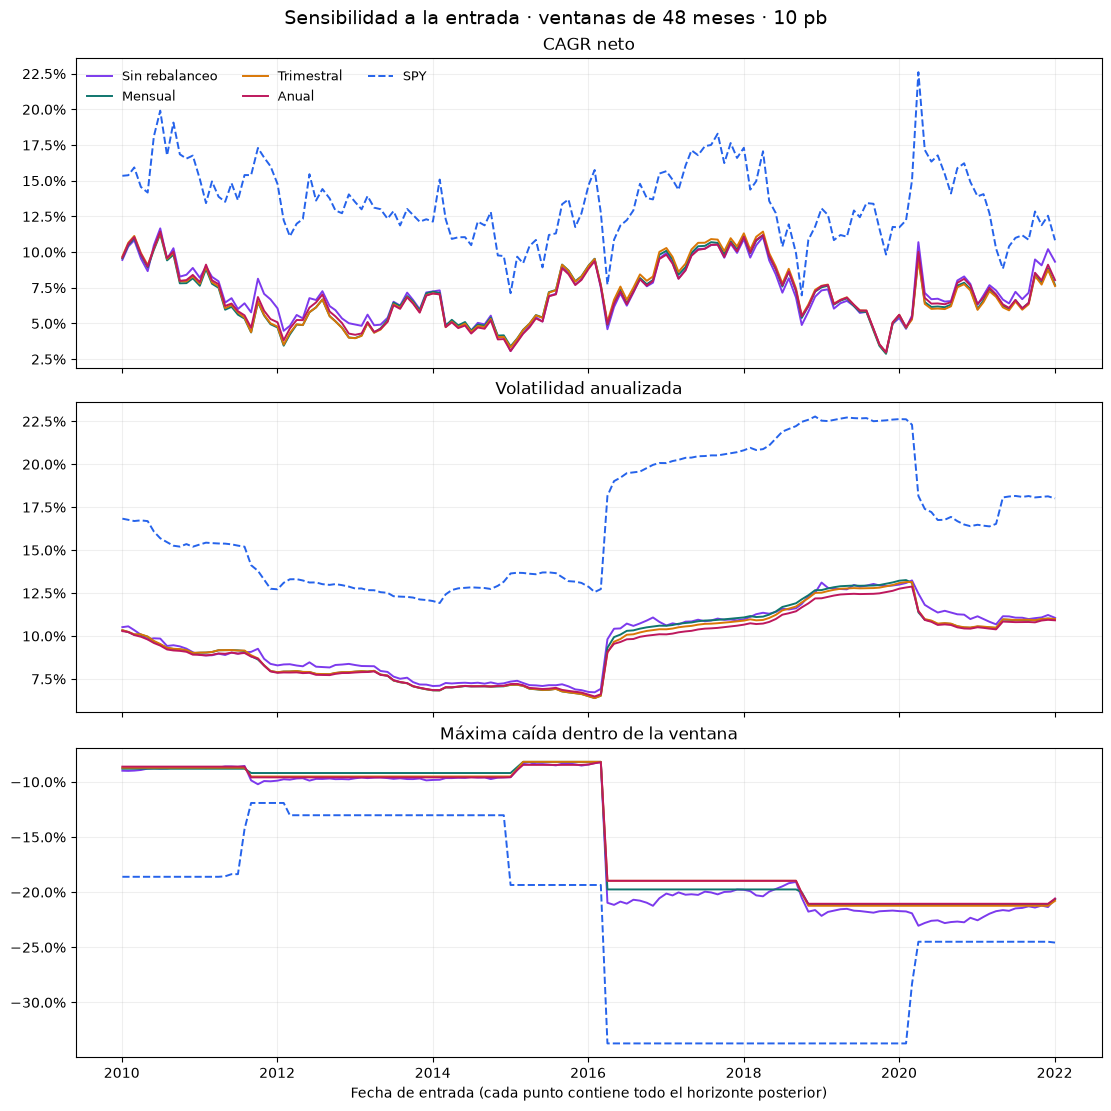

In [28]:
cagr_movil = resultados_moviles["CAGR"].unstack("Estrategia").reindex(index=ventanas_moviles.index, columns=estrategias_moviles)
volatilidad_movil = resultados_moviles["Volatilidad anualizada"].unstack("Estrategia").reindex_like(cagr_movil)
caidas_moviles = resultados_moviles["Máxima caída"].unstack("Estrategia").reindex_like(cagr_movil)
colores_moviles = {"Sin rebalanceo": "#7c3aed", "Mensual": "#0f766e", "Trimestral": "#d97706", "Anual": "#be185d", "SPY": "#2563eb"}
fig, ejes = plt.subplots(3, 1, figsize=(11, 11), sharex=True, layout="constrained")
for ax, matriz, titulo in zip(ejes, [cagr_movil, volatilidad_movil, caidas_moviles],
                              ["CAGR neto", "Volatilidad anualizada", "Máxima caída dentro de la ventana"]):
    for nombre in estrategias_moviles:
        ax.plot(ventanas_moviles["Inicio real"], matriz[nombre], label=nombre,
                color=colores_moviles[nombre], ls="--" if nombre == "SPY" else "-", lw=1.4)
    ax.set_title(titulo)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=0.2)
ejes[0].legend(ncol=3, frameon=False, fontsize=9)
ejes[2].set_xlabel("Fecha de entrada (cada punto contiene todo el horizonte posterior)")
fig.suptitle(f"Sensibilidad a la entrada · ventanas de {MESES_VENTANA} meses · {COSTO_BPS:g} pb", fontsize=14)
plt.show()

### Dispersión de resultados y experiencias extremas

El CAGR de mantener posiciones varía entre **2.93% y 11.66%**, con mediana de
**6.98%**. La política mensual presenta un rango de **2.88% a 11.26%** y una
mediana de **6.62%**; las medianas trimestral y anual son **6.66% y 6.81%**.
La dispersión entre fechas de entrada es apreciable respecto de las diferencias
entre las medianas de las reglas.

Los CAGR mínimos positivos indican que no se observaron pérdidas entre los
extremos de estas ventanas para los cuatro portafolios. Ello convive con caídas
intermedias y no establece un horizonte seguro de recuperación. La columna
«peor caída observada» recoge el drawdown más profundo entre ventanas; no es
una mediana ni el peor CAGR. La proporción de ventanas con pérdida describe
exclusivamente el historial utilizado.

In [29]:
resumen_moviles = pd.DataFrame({
    "CAGR mínimo": cagr_movil.min(), "CAGR mediano": cagr_movil.median(), "CAGR máximo": cagr_movil.max(),
    "Volatilidad mediana": volatilidad_movil.median(), "Peor caída observada": caidas_moviles.min(),
    "Ventanas con pérdida": (cagr_movil < -1e-10).mean(),
}).reindex(estrategias_moviles)
display(resumen_moviles.style.format("{:.2%}").set_caption("Resumen descriptivo entre fechas de entrada"))

extremos_entrada = []
for nombre in estrategias_moviles:
    for tipo, etiqueta in [("Menor CAGR", cagr_movil[nombre].idxmin()), ("Mayor CAGR", cagr_movil[nombre].idxmax())]:
        fila = resultados_moviles.loc[(etiqueta, nombre)]
        extremos_entrada.append({"Estrategia": nombre, "Extremo": tipo,
                                "Entrada": fila["Inicio real"], "Salida": fila["Fin real"], "CAGR": fila["CAGR"]})
extremos_entrada = pd.DataFrame(extremos_entrada).set_index(["Estrategia", "Extremo"])
display(extremos_entrada.style.format({
    "Entrada": lambda fecha: fecha.strftime("%Y-%m-%d"),
    "Salida": lambda fecha: fecha.strftime("%Y-%m-%d"), "CAGR": "{:.2%}",
}).set_caption("Fechas de los extremos de CAGR; se muestra la primera fecha si hay empate exacto"))

,CAGR mínimo,CAGR mediano,CAGR máximo,Volatilidad mediana,Peor caída observada,Ventanas con pérdida
Estrategia,,,,,,
Sin rebalanceo,2.93%,6.98%,11.66%,10.08%,-23.05%,0.00%
Mensual,2.88%,6.62%,11.26%,9.96%,-21.10%,0.00%
Trimestral,2.97%,6.66%,11.44%,9.83%,-21.23%,0.00%
Anual,2.98%,6.81%,11.44%,9.65%,-21.05%,0.00%
SPY,6.97%,13.11%,22.60%,16.42%,-33.72%,0.00%


### Comparaciones pareadas frente a mantener posiciones

Se resta, dentro de cada ventana, el CAGR sin rebalanceo al de cada frecuencia.
El resultado se expresa en puntos porcentuales anuales y permite comparar
decisiones sobre las mismas fechas. Las proporciones de ventanas con mayor CAGR
son **46.2% para mensual**, **46.9% para trimestral** y **33.1% para anual**.

Ninguna frecuencia supera a mantener posiciones en la mayoría de las ventanas
observadas según este criterio. Este resultado no implica dominancia en riesgo:
las exposiciones divergen y deben contrastarse también volatilidad y caídas.
La volatilidad, en cambio, es inferior a la de mantener posiciones en **76.6%,
87.6% y 96.6%** de las ventanas para mensual, trimestral y anual, respectivamente.
Las diferencias deben superar $10^{-10}$ en la tasa para contar como superioridad;
los empates permanecen en el denominador, pero no se cuentan como victorias.

,CAGR superior a sin rebalanceo,Brecha mediana CAGR (pp),CAGR superior a SPY,Menor volatilidad que sin rebalanceo
Estrategia,,,,
Mensual,46.2%,-0.054,0.0%,76.6%
Trimestral,46.9%,-0.020,0.0%,87.6%
Anual,33.1%,-0.123,0.0%,96.6%


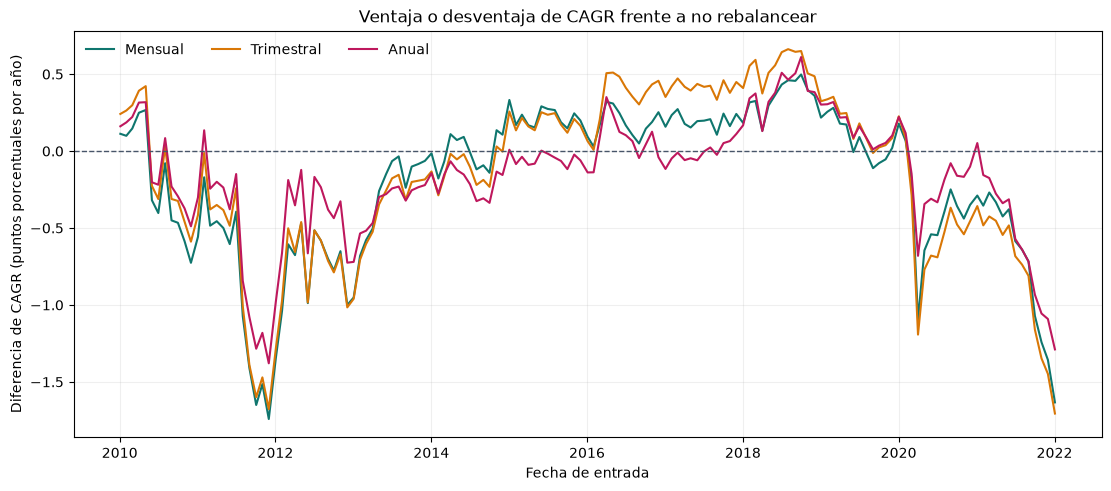

In [30]:
reglas_periodicas = [nombre for nombre, frecuencia in FRECUENCIAS.items() if frecuencia != "sin rebalanceo"]
brechas_cagr = cagr_movil[reglas_periodicas].sub(cagr_movil["Sin rebalanceo"], axis=0)
comparaciones_pareadas = pd.DataFrame({
    "CAGR superior a sin rebalanceo": (brechas_cagr > 1e-10).mean(),
    "Brecha mediana CAGR (pp)": brechas_cagr.median() * 100,
    "CAGR superior a SPY": cagr_movil[reglas_periodicas].sub(cagr_movil["SPY"], axis=0).gt(1e-10).mean(),
    "Menor volatilidad que sin rebalanceo": volatilidad_movil[reglas_periodicas].sub(volatilidad_movil["Sin rebalanceo"], axis=0).lt(-1e-10).mean(),
})
display(comparaciones_pareadas.style.format({
    "CAGR superior a sin rebalanceo": "{:.1%}", "Brecha mediana CAGR (pp)": "{:+.3f}",
    "CAGR superior a SPY": "{:.1%}", "Menor volatilidad que sin rebalanceo": "{:.1%}",
}).set_caption("Frecuencias descriptivas de comparación por ventana"))

fig, ax = plt.subplots(figsize=(11, 4.8), layout="constrained")
for nombre in reglas_periodicas:
    ax.plot(ventanas_moviles["Inicio real"], brechas_cagr[nombre] * 100,
            label=nombre, color=colores_moviles[nombre], lw=1.5)
ax.axhline(0, color="#475569", ls="--", lw=1)
ax.set(title="Ventaja o desventaja de CAGR frente a no rebalancear",
       xlabel="Fecha de entrada", ylabel="Diferencia de CAGR (puntos porcentuales por año)")
ax.legend(ncol=3, frameon=False)
ax.grid(alpha=0.2)
plt.show()

### Liderazgo descriptivo por objetivo

La cuota de mayor CAGR entre las cuatro políticas es **48.3% para mantener
posiciones**, **31.7% para trimestral**, **13.1% para mensual** y **6.9% para anual**.
El primer lugar agregado de mantener posiciones convive así con numerosas
ventanas en las que otra regla obtiene mayor crecimiento.

La política anual lidera por menor volatilidad en una cuota de **71.0%** y por
caída menos profunda en **48.6%**. Se calculan clasificaciones separadas por
criterio; SPY no participa en este ranking de políticas de rebalanceo. Si hay
empate entre $k$ reglas, cada una recibe $1/k$ de esa ventana, de modo que las
cuotas por criterio suman 100%. La tolerancia es $10^{-10}$ sobre la métrica
sin redondear. Estas cuotas no tienen una interpretación probabilística futura.

In [31]:
liderazgos_moviles = {
    "Mayor CAGR": cuotas_liderazgo(cagr_movil[list(FRECUENCIAS)]),
    "Menor volatilidad": cuotas_liderazgo(volatilidad_movil[list(FRECUENCIAS)], maximizar=False),
    "Caída menos profunda": cuotas_liderazgo(caidas_moviles[list(FRECUENCIAS)]),
}
cuotas_moviles = pd.DataFrame({criterio: tabla["Cuota descriptiva"] for criterio, tabla in liderazgos_moviles.items()})
display(cuotas_moviles.style.format("{:.1%}").set_caption("Cuota de liderazgo por criterio, repartiendo empates"))

,Mayor CAGR,Menor volatilidad,Caída menos profunda
Estrategia,,,
Sin rebalanceo,48.3%,3.4%,2.4%
Mensual,13.1%,20.7%,29.7%
Trimestral,31.7%,4.8%,19.3%
Anual,6.9%,71.0%,48.6%


### Validación de las ventanas

Los controles verifican cobertura, duración efectiva, número de simulaciones y
normalización de las cuotas de liderazgo. Las curvas sin rebalanceo y SPY se
contrastan con su identidad analítica de compra y mantenimiento, además de
los controles de entrada y costos del motor.

Las pruebas con datos sintéticos contemplan meses faltantes y periodos parciales.
También verifican que modificar precios externos a una ventana no cambie su
resultado. Estas comprobaciones permiten interpretar la variación entre fechas
como sensibilidad del experimento y reducen el riesgo de atribuir a la estrategia
un error de delimitación temporal.

In [32]:
assert resultados_moviles.index.is_unique
assert len(resultados_moviles) == len(ventanas_moviles) * len(estrategias_moviles)
assert (ventanas_moviles["Fin solicitado"] <= precios.index[-1].normalize()).all()
assert (ventanas_moviles["Inicio real"] >= ventanas_moviles["Inicio solicitado"]).all()
assert (ventanas_moviles["Fin real"] <= ventanas_moviles["Fin solicitado"]).all()
assert np.isfinite(resultados_moviles[["CAGR", "Volatilidad anualizada", "Máxima caída", "Valor final (USD)"]].to_numpy()).all()
np.testing.assert_allclose(
    resultados_moviles["CAGR"],
    (resultados_moviles["Valor final (USD)"] / CAPITAL_INICIAL) ** (1 / resultados_moviles["Años efectivos"]) - 1,
    rtol=1e-12, atol=1e-12,
)
np.testing.assert_allclose(cuotas_moviles.sum(), 1, atol=1e-12)
# Un empate exacto de cuatro reglas aporta 25% a cada una.
prueba_empate = cuotas_liderazgo(pd.DataFrame([[1., 1., 1., 1.]], columns=list(FRECUENCIAS)))
np.testing.assert_allclose(prueba_empate["Cuota descriptiva"], .25)

if MESES_VENTANA == 48:
    limites_eventos = {"sin rebalanceo": {0}, "mensual": {47}, "trimestral": {15, 16}, "anual": {3, 4}}
    for nombre, frecuencia in FRECUENCIAS.items():
        assert set(resultados_moviles.xs(nombre, level="Estrategia")["Rebalanceos"]).issubset(limites_eventos[frecuencia])

print(f"Controles correctos: {len(ventanas_moviles)} ventanas y {len(resultados_moviles)} simulaciones.")
for nombre in FRECUENCIAS:
    print(f"{nombre}: CAGR mínimo {resumen_moviles.loc[nombre, 'CAGR mínimo']:.2%}, "
          f"mediano {resumen_moviles.loc[nombre, 'CAGR mediano']:.2%}, "
          f"máximo {resumen_moviles.loc[nombre, 'CAGR máximo']:.2%}; "
          f"cuota de mayor CAGR {cuotas_moviles.loc[nombre, 'Mayor CAGR']:.1%}.")
for nombre in reglas_periodicas:
    print(f"{nombre} supera el CAGR de no rebalancear en "
          f"{comparaciones_pareadas.loc[nombre, 'CAGR superior a sin rebalanceo']:.1%} de las ventanas observadas.")
print("Las cuotas anteriores describen ventanas solapadas; no son probabilidades futuras.")

Controles correctos: 145 ventanas y 725 simulaciones.
Sin rebalanceo: CAGR mínimo 2.93%, mediano 6.98%, máximo 11.66%; cuota de mayor CAGR 48.3%.
Mensual: CAGR mínimo 2.88%, mediano 6.62%, máximo 11.26%; cuota de mayor CAGR 13.1%.
Trimestral: CAGR mínimo 2.97%, mediano 6.66%, máximo 11.44%; cuota de mayor CAGR 31.7%.
Anual: CAGR mínimo 2.98%, mediano 6.81%, máximo 11.44%; cuota de mayor CAGR 6.9%.
Mensual supera el CAGR de no rebalancear en 46.2% de las ventanas observadas.
Trimestral supera el CAGR de no rebalancear en 46.9% de las ventanas observadas.
Anual supera el CAGR de no rebalancear en 33.1% de las ventanas observadas.
Las cuotas anteriores describen ventanas solapadas; no son probabilidades futuras.


### Conclusión sobre la fecha de entrada

La posición relativa de las políticas cambia al desplazar el inicio. Mantener
posiciones conserva la mayor mediana de CAGR entre las cuatro reglas, pero su
cuota de liderazgo queda por debajo del 50%. La frecuencia trimestral muestra
más liderazgo por crecimiento que mensual y anual, sin dominar el conjunto
de experiencias.

La mediana de ventanas resume inversiones alternativas; no representa el CAGR
de una estrategia invertible que las combine. Las ventanas comparten observaciones,
por lo que aumentar su número no equivale a disponer de 145 pruebas independientes.
El estudio de bandas conserva este mismo esquema de comparación para evaluar
si condicionar la negociación a la desviación de pesos reduce actividad.

`MESES_VENTANA` y `PASO_MESES` permiten explorar otros horizontes. La cobertura
y los resultados completos quedan en `ventanas_moviles` y `resultados_moviles`.

## 6. Rebalanceo por bandas: desviación, actividad y riesgo

Las bandas sustituyen la periodicidad fija por una condición sobre la composición.
Se evalúan umbrales de **±2.5, ±5 y ±10 puntos porcentuales** respecto del objetivo
de 25% por activo. La banda ±5 pp, por ejemplo, establece límites de 20% y 30%;
se trata de una distancia en puntos porcentuales, no de 5% relativo a 25%.

Después del rendimiento de cada sesión se revisan los pesos. Si al menos uno
supera el límite, se restaura **todo el portafolio** a sus objetivos, pagando
los cargos correspondientes. No se corrige únicamente el activo desviado ni se
opera solo hasta el borde. La igualdad exacta no activa la regla; la comparación
utiliza una tolerancia de $10^{-12}$ en el peso.

Esta sección conserva la ejecución idealizada al mismo cierre y omite operaciones
en las fechas inicial y terminal. Un movimiento diario puede atravesar el umbral
antes de operar; el último cierre puede quedar fuera de banda. Por tanto, el
umbral es un disparador de negociación y no un límite garantizado de pérdidas
ni de desviación en todo momento.

Los tres umbrales son escenarios fijados para el experimento y no el resultado
de una optimización. ±5 pp se utiliza como caso principal para facilitar la lectura.
La evaluación incluye la muestra completa y comparaciones pareadas frente al
mensual sobre las mismas 145 ventanas.

In [33]:
BANDAS_PRUEBA_PP = [2.5, 5.0, 10.0]
BANDA_PRINCIPAL_PP = 5.0  # Se usa en las gráficas de trayectoria y desviación.

In [34]:
# Investigación por bandas: resúmenes y comparación pareada en ventanas.
def construir_politicas_bandas(bandas_pp, banda_principal_pp):
    """Valida antes de convertir y genera etiquetas que conservan cada umbral distinto."""
    originales = [banda_principal_pp, *list(bandas_pp)]
    for valor in originales:
        if (isinstance(valor, (bool, np.bool_))
                or not isinstance(valor, (int, float, np.integer, np.floating))
                or not np.isfinite(valor) or not 0 < valor < 100):
            raise ValueError("Cada banda debe ser numérica, finita y estrictamente entre 0 y 100 pp.")
    bandas = sorted(set(map(float, originales)))

    def etiqueta(valor):
        numero = float(valor)
        texto = str(int(numero)) if numero.is_integer() else repr(numero)
        return f"Banda ±{texto} pp"

    politicas = {etiqueta(valor): {"frecuencia": "bandas", "banda_pp": valor} for valor in bandas}
    return politicas, etiqueta(banda_principal_pp)


def resumir_operativa(resultado, pesos):
    '''Volumen a dos lados y deriva de pesos, con las mismas unidades de secciones previas.'''
    registro = resultado["operaciones"]
    operaciones = registro.loc[registro["Motivo"].str.startswith("Rebalanceo ")]
    patrimonio = resultado["patrimonio"]
    anios = (patrimonio.index[-1] - patrimonio.index[0]).days / 365.25
    objetivo = pd.Series(pesos).reindex(resultado["pesos"].columns)
    return pd.Series({
        "Volumen relativo anual": operaciones["Volumen / patrimonio"].sum() / anios,
        "Desvío mediano antes de operar (pp)": resultado["pesos_antes"].sub(objetivo, axis=1).abs().max(axis=1).iloc[1:].median() * 100,
        "Desvío máximo después de operar (pp)": resultado["pesos"].sub(objetivo, axis=1).abs().max(axis=1).max() * 100,
    })


def comparar_bandas_en_ventanas(precios, pesos, capital, costo, ventanas, politicas):
    '''Evalúa bandas y mensual sobre idénticas ventanas, usando el motor común.'''
    filas = []
    for etiqueta, ventana in ventanas.iterrows():
        bloque = precios.loc[ventana["Inicio real"]:ventana["Fin real"]]
        for nombre, argumentos in politicas.items():
            resultado = simular_portafolio(bloque, pesos, capital, costo, **argumentos)
            filas.append({
                "Ventana": etiqueta, "Estrategia": nombre,
                **ventana.to_dict(), **resumir_backtest(resultado).to_dict(),
                **resumir_operativa(resultado, pesos).to_dict(),
            })
    return pd.DataFrame(filas).set_index(["Ventana", "Estrategia"])

In [35]:
# Validar los valores originales antes de convertirlos e incluir la banda principal.
politicas_bandas, nombre_banda_principal = construir_politicas_bandas(BANDAS_PRUEBA_PP, BANDA_PRINCIPAL_PP)
bandas_activas = [argumentos["banda_pp"] for argumentos in politicas_bandas.values()]
politicas_comparadas = {**{nombre: {"frecuencia": frecuencia} for nombre, frecuencia in FRECUENCIAS.items()}, **politicas_bandas}
resultados_bandas = {}
resultados_bandas_cero = {}
for nombre, argumentos in politicas_comparadas.items():
    resultados_bandas[nombre] = simular_portafolio(precios, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTO_BPS, **argumentos)
    resultados_bandas_cero[nombre] = simular_portafolio(precios, PESOS_OBJETIVO, CAPITAL_INICIAL, 0.0, **argumentos)
resultados_bandas["SPY"] = simular_portafolio(precios[["SPY"]], {"SPY": 1.0}, CAPITAL_INICIAL, COSTO_BPS, frecuencia="sin rebalanceo")
resumen_bandas = pd.DataFrame({nombre: resumir_backtest(resultado) for nombre, resultado in resultados_bandas.items()}).T
resumen_bandas.index.name = "Estrategia"
print(f"Capital: {CAPITAL_INICIAL:,.2f} USD | Costo: {COSTO_BPS:g} pb | Bandas: {bandas_activas} pp.")
display(resumen_bandas.style.format({
    "Valor final (USD)": "{:,.2f}", "Rendimiento acumulado": "{:.2%}", "CAGR": "{:.2%}",
    "Volatilidad anualizada": "{:.2%}", "Máxima caída": "{:.2%}", "Costos pagados (USD)": "{:,.2f}", "Rebalanceos": "{:.0f}",
}).set_caption("Muestra completa: reglas de calendario, bandas y SPY"))

Capital: 10,000.00 USD | Costo: 10 pb | Bandas: [2.5, 5.0, 10.0] pp.


,Valor final (USD),Rendimiento acumulado,CAGR,Volatilidad anualizada,Máxima caída,Costos pagados (USD),Rebalanceos
Estrategia,,,,,,,
Sin rebalanceo,"42,181.09",321.81%,9.42%,11.70%,-25.95%,9.99,0
Mensual,"38,991.30",289.91%,8.88%,9.95%,-21.10%,99.56,191
Trimestral,"39,204.39",292.04%,8.92%,9.91%,-21.23%,63.10,63
Anual,"39,285.05",292.85%,8.93%,9.81%,-21.05%,34.19,15
Banda ±2.5 pp,"39,731.46",297.31%,9.01%,10.06%,-21.25%,63.42,40
Banda ±5 pp,"40,551.17",305.51%,9.15%,10.12%,-21.31%,41.08,11
Banda ±10 pp,"40,664.93",306.65%,9.17%,10.14%,-21.24%,28.62,3
SPY,"80,119.37",701.19%,13.90%,17.21%,-33.72%,9.99,0


### Costos, volumen y distancia respecto al objetivo

La actividad cae al ampliar el umbral: las bandas ±2.5, ±5 y ±10 pp registran
**40, 11 y 3 rebalanceos**, frente a 191 mensuales. Sus cargos nominales son
**63.42, 41.08 y 28.62 USD**, respectivamente, frente a **99.56 USD** del mensual.
Los importes incluyen la compra inicial y corresponden al cargo base de 10 pb.

La tabla complementa estos conteos con volumen relativo anual y deriva de pesos.
El volumen suma compras y ventas sobre patrimonio previo, excluye la entrada y
se divide entre los años efectivos. El desvío diario es la mayor distancia absoluta
entre un peso y su objetivo, expresada en puntos porcentuales.

Menos operaciones permite aceptar más deriva antes de restaurar la asignación.
En la banda ±5 pp, el volumen relativo anual es **9.06%**, frente a **27.85%**
del mensual, y el desvío diario mediano previo es **2.43 pp frente a 0.61 pp**.
La desviación máxima posterior incluye la última fecha sin rebalanceo; por ello
puede superar el umbral. Este detalle es relevante al interpretar la banda como
herramienta de control de composición.

In [36]:
operativa_bandas = pd.DataFrame({
    nombre: resumir_operativa(resultados_bandas[nombre], PESOS_OBJETIVO) for nombre in politicas_comparadas
}).T
operativa_bandas["Costos pagados (USD)"] = resumen_bandas.loc[operativa_bandas.index, "Costos pagados (USD)"]
operativa_bandas["Impacto en valor final (USD)"] = [
    resultados_bandas_cero[nombre]["patrimonio"].iloc[-1] - resultados_bandas[nombre]["patrimonio"].iloc[-1]
    for nombre in operativa_bandas.index
]
display(operativa_bandas.style.format({
    "Volumen relativo anual": "{:.2%}", "Desvío mediano antes de operar (pp)": "{:.2f}",
    "Desvío máximo después de operar (pp)": "{:.2f}", "Costos pagados (USD)": "{:,.2f}",
    "Impacto en valor final (USD)": "{:,.2f}",
}).set_caption("Operaciones y distancia respecto a los pesos objetivo"))

,Volumen relativo anual,Desvío mediano antes de operar (pp),Desvío máximo después de operar (pp),Costos pagados (USD),Impacto en valor final (USD)
Sin rebalanceo,0.00%,10.69,24.13,9.99,42.18
Mensual,27.85%,0.61,5.85,99.56,213.19
Trimestral,16.48%,1.04,7.01,63.10,142.76
Anual,7.11%,2.03,9.20,34.19,84.04
Banda ±2.5 pp,15.69%,1.18,2.50,63.42,139.65
Banda ±5 pp,9.06%,2.43,4.99,41.08,99.39
Banda ±10 pp,4.56%,3.65,9.98,28.62,70.35


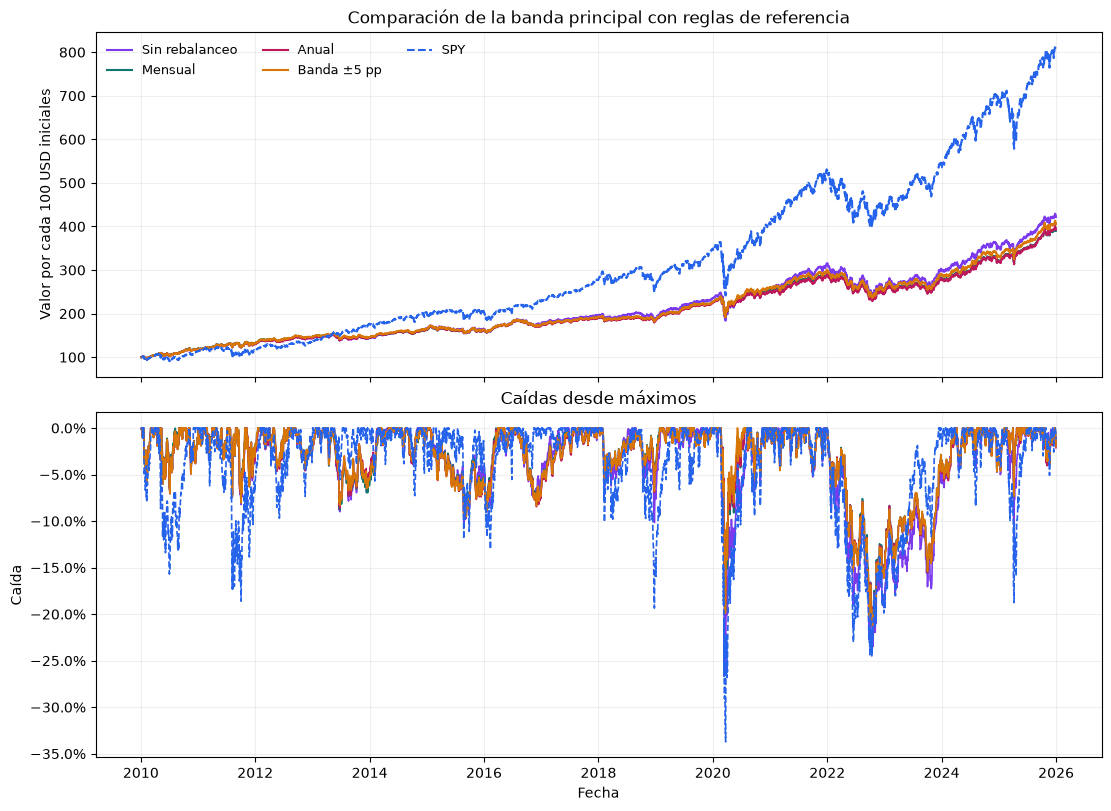

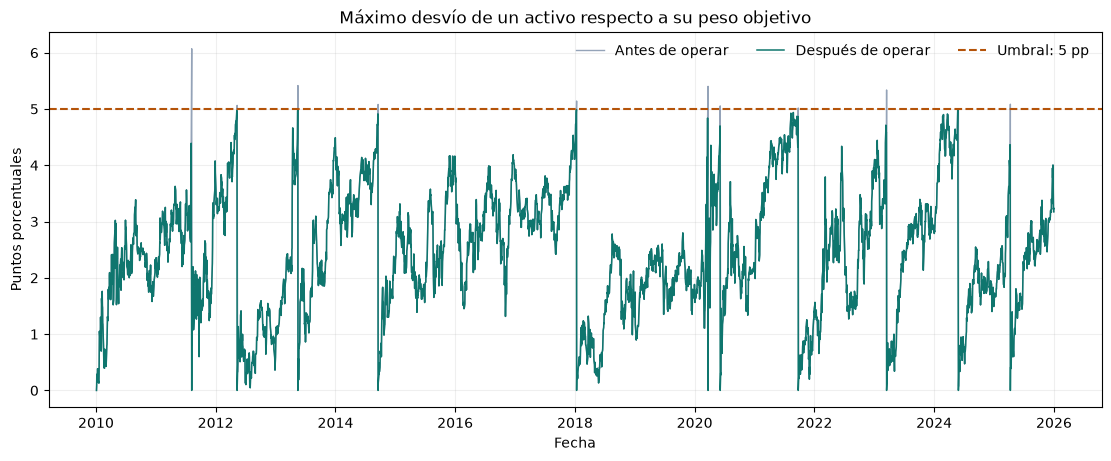

In [37]:
seleccion_trayectorias = ["Sin rebalanceo", "Mensual", "Anual", nombre_banda_principal, "SPY"]
colores_bandas = {"Sin rebalanceo": "#7c3aed", "Mensual": "#0f766e", "Anual": "#be185d", nombre_banda_principal: "#d97706", "SPY": "#2563eb"}
fig, ejes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, layout="constrained")
for nombre in seleccion_trayectorias:
    resultado = resultados_bandas[nombre]
    estilo = "--" if nombre == "SPY" else "-"
    ejes[0].plot(precios.index, resultado["patrimonio"] / CAPITAL_INICIAL * 100,
                 color=colores_bandas[nombre], ls=estilo, lw=1.5, label=nombre)
    ejes[1].plot(precios.index, resultado["drawdown"], color=colores_bandas[nombre], ls=estilo, lw=1.2)
ejes[0].set(title="Comparación de la banda principal con reglas de referencia", ylabel="Valor por cada 100 USD iniciales")
ejes[0].legend(ncol=3, frameon=False, fontsize=9)
ejes[1].set(title="Caídas desde máximos", ylabel="Caída", xlabel="Fecha")
ejes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in ejes:
    ax.grid(alpha=0.2)
plt.show()

principal = resultados_bandas[nombre_banda_principal]
desvio_antes = principal["pesos_antes"].sub(PESOS_OBJETIVO, axis=1).abs().max(axis=1) * 100
desvio_despues = principal["pesos"].sub(PESOS_OBJETIVO, axis=1).abs().max(axis=1) * 100
fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
ax.plot(precios.index, desvio_antes, color="#94a3b8", lw=1, label="Antes de operar")
ax.plot(precios.index, desvio_despues, color="#0f766e", lw=1.1, label="Después de operar")
ax.axhline(BANDA_PRINCIPAL_PP, color="#b45309", ls="--", label=f"Umbral: {BANDA_PRINCIPAL_PP:g} pp")
ax.set(title="Máximo desvío de un activo respecto a su peso objetivo", ylabel="Puntos porcentuales", xlabel="Fecha")
ax.legend(ncol=3, frameon=False)
ax.grid(alpha=0.2)
plt.show()

### Auditoría de activaciones y restauración de pesos

El registro de la banda principal presenta el desvío previo y las compras,
ventas y cargos de las primeras y últimas activaciones. Se comprueba que cada
cruce interior estricto genere una operación y que, después de ella, todos
los pesos regresen al objetivo. La financiación de costos se valida con la
misma identidad patrimonial utilizada en las reglas de calendario.

La señal utiliza los pesos observados tras el rendimiento de la sesión, sin
consultar retornos posteriores. Esa causalidad de la señal debe distinguirse
del supuesto de poder negociar al cierre recién observado. La sección 7
relaja este último supuesto y conserva un registro separado de señal y ejecución.

In [38]:
for nombre, argumentos in politicas_bandas.items():
    resultado = resultados_bandas[nombre]
    banda = argumentos["banda_pp"]
    antes = resultado["pesos_antes"].sub(PESOS_OBJETIVO, axis=1).abs().max(axis=1)
    fechas_cruce = antes.iloc[1:-1].index[antes.iloc[1:-1] > banda / 100 + 1e-12]
    operaciones = resultado["operaciones"]
    fechas_operadas = operaciones.index[operaciones["Motivo"].str.startswith("Rebalanceo ")]
    assert fechas_cruce.equals(fechas_operadas)
    np.testing.assert_allclose(resultado["pesos"].loc[fechas_operadas], np.tile(PESOS_OBJETIVO.reindex(precios.columns), (len(fechas_operadas), 1)), atol=1e-12)
    assert (resultado["pesos"].iloc[1:-1].sub(PESOS_OBJETIVO, axis=1).abs().max(axis=1) <= banda / 100 + 2e-12).all()
    np.testing.assert_allclose(operaciones["Valor después"] + operaciones["Costo"], operaciones["Valor antes"], rtol=1e-12)
    np.testing.assert_allclose(operaciones["Costo"], operaciones["Volumen operado"] * COSTO_BPS / 10_000, atol=1e-8)
    # Con retorno a pesos fijos y costos proporcionales, el costo no cambia el calendario de cruces.
    assert operaciones.index.equals(resultados_bandas_cero[nombre]["operaciones"].index)

registro_banda_principal = principal["operaciones"].iloc[1:].copy()
registro_banda_principal["Desvío previo (pp)"] = desvio_antes.reindex(registro_banda_principal.index)
vista_banda = pd.concat([registro_banda_principal.head(3), registro_banda_principal.tail(3)])
vista_banda = vista_banda.loc[~vista_banda.index.duplicated()]
display(vista_banda[["Desvío previo (pp)", "Compras", "Ventas", "Costo"]].style.format("{:,.2f}").format_index(lambda fecha: fecha.strftime("%Y-%m-%d")))
print("Controles correctos: cruces, retorno a objetivos y financiación de costos.")

,Desvío previo (pp),Compras,Ventas,Costo
Fecha,,,,
2011-08-08,6.07,741.49,742.98,1.48
2012-05-11,5.06,951.90,953.80,1.91
2013-05-17,5.42,"1,068.29","1,070.43",2.14
2023-03-17,5.34,"1,402.79","1,405.60",2.81
2024-05-28,5.00,"1,766.91","1,770.44",3.54
2025-04-10,5.08,"1,708.35","1,711.77",3.42


Controles correctos: cruces, retorno a objetivos y financiación de costos.


### Comparación de bandas y mensual en ventanas móviles

Se realizan **580 simulaciones**: las tres bandas y el calendario mensual en
145 ventanas de 48 meses. Cada comparación comparte fechas, capital y costo,
reiniciando posiciones en cada inversión.

La banda ±5 pp obtiene mayor CAGR que mensual en **74.5% de las ventanas**, con
una brecha mediana de **+0.200 pp anuales**. Las bandas ±2.5 y ±10 pp lo superan
en **64.1% y 53.8%**, con brechas medianas de **+0.071 y +0.054 pp**. Ampliar
el umbral no mejora de forma uniforme estas comparaciones de crecimiento.

La reducción de actividad tampoco implica una mejora general de riesgo. La
banda ±5 pp registra menor volatilidad que mensual en solo **16.6%** de las
ventanas y una caída menos profunda en **20.7%**. Su ventaja de CAGR suele
acompañarse de una exposición de riesgo algo mayor según estas medidas.

Las diferencias de volumen relativo anual se expresan en puntos porcentuales;
un valor negativo frente al mensual significa menor actividad. Las cuotas de
superioridad incluyen todos los casos en el denominador y excluyen empates del
numerador. Por el solapamiento, su interpretación es descriptiva y no probabilística.

,CAGR mediano,CAGR superior al mensual,Brecha mediana CAGR (pp),Menor volatilidad que mensual,Caída menos profunda que mensual,Cambio mediano volumen anual (pp)
Estrategia,,,,,,
Banda ±2.5 pp,6.71%,64.1%,+0.071,6.9%,8.3%,-13.25
Banda ±5 pp,6.82%,74.5%,+0.200,16.6%,20.7%,-18.91
Banda ±10 pp,6.89%,53.8%,+0.054,29.0%,17.2%,-24.30


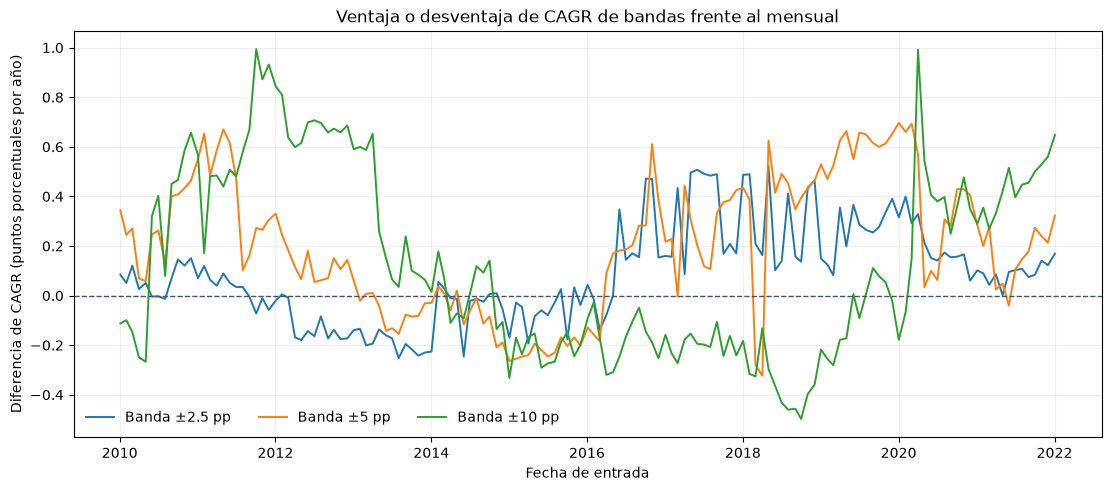

Ventanas: 145; simulaciones adicionales: 580.


In [39]:
ventanas_bandas = construir_ventanas_mensuales(precios, MESES_VENTANA, PASO_MESES)
politicas_ventanas_bandas = {"Mensual": {"frecuencia": "mensual"}, **politicas_bandas}
resultados_ventanas_bandas = comparar_bandas_en_ventanas(
    precios, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTO_BPS, ventanas_bandas, politicas_ventanas_bandas,
)
assert len(resultados_ventanas_bandas) == len(ventanas_bandas) * len(politicas_ventanas_bandas)
assert resultados_ventanas_bandas.index.is_unique
matriz_cagr_bandas = resultados_ventanas_bandas["CAGR"].unstack("Estrategia").reindex(ventanas_bandas.index)
matriz_vol_bandas = resultados_ventanas_bandas["Volatilidad anualizada"].unstack("Estrategia").reindex(ventanas_bandas.index)
matriz_caidas_bandas = resultados_ventanas_bandas["Máxima caída"].unstack("Estrategia").reindex(ventanas_bandas.index)
matriz_volumen_bandas = resultados_ventanas_bandas["Volumen relativo anual"].unstack("Estrategia").reindex(ventanas_bandas.index)
brechas_bandas = matriz_cagr_bandas[list(politicas_bandas)].sub(matriz_cagr_bandas["Mensual"], axis=0)
resumen_ventanas_bandas = pd.DataFrame({
    "CAGR mediano": matriz_cagr_bandas[list(politicas_bandas)].median(),
    "CAGR superior al mensual": (brechas_bandas > 1e-10).mean(),
    "Brecha mediana CAGR (pp)": brechas_bandas.median() * 100,
    "Menor volatilidad que mensual": matriz_vol_bandas[list(politicas_bandas)].sub(matriz_vol_bandas["Mensual"], axis=0).lt(-1e-10).mean(),
    "Caída menos profunda que mensual": matriz_caidas_bandas[list(politicas_bandas)].sub(matriz_caidas_bandas["Mensual"], axis=0).gt(1e-10).mean(),
    "Cambio mediano volumen anual (pp)": matriz_volumen_bandas[list(politicas_bandas)].sub(matriz_volumen_bandas["Mensual"], axis=0).median() * 100,
})
display(resumen_ventanas_bandas.style.format({
    "CAGR mediano": "{:.2%}", "CAGR superior al mensual": "{:.1%}", "Brecha mediana CAGR (pp)": "{:+.3f}",
    "Menor volatilidad que mensual": "{:.1%}", "Caída menos profunda que mensual": "{:.1%}", "Cambio mediano volumen anual (pp)": "{:+.2f}",
}).set_caption("Bandas frente a mensual, sobre idénticas ventanas"))

fig, ax = plt.subplots(figsize=(11, 4.8), layout="constrained")
for nombre in politicas_bandas:
    ax.plot(ventanas_bandas["Inicio real"], brechas_bandas[nombre] * 100, label=nombre, lw=1.4)
ax.axhline(0, color="#475569", ls="--", lw=1)
ax.set(title="Ventaja o desventaja de CAGR de bandas frente al mensual", xlabel="Fecha de entrada", ylabel="Diferencia de CAGR (puntos porcentuales por año)")
ax.legend(ncol=min(3, len(politicas_bandas)), frameon=False)
ax.grid(alpha=0.2)
plt.show()
print(f"Ventanas: {len(ventanas_bandas)}; simulaciones adicionales: {len(resultados_ventanas_bandas)}.")

### Resultados e interpretación de las bandas

En la muestra completa, con ejecución al mismo cierre:

| Regla | CAGR | Volatilidad anualizada | Máxima caída | Rebalanceos |
|---|---:|---:|---:|---:|
| Mensual | 8.88% | 9.95% | −21.10% | 191 |
| Banda ±2.5 pp | 9.01% | 10.06% | −21.25% | 40 |
| Banda ±5 pp | 9.15% | 10.12% | −21.31% | 11 |
| Banda ±10 pp | 9.17% | 10.14% | −21.24% | 3 |

Las bandas combinan menos negociación y mayor crecimiento observado con algo
más de volatilidad y caídas ligeramente más profundas que el mensual. El resultado
refleja el intercambio entre actividad y deriva, además de los costos; no puede
atribuirse íntegramente al ahorro de cargos.

±10 pp logra el mayor CAGR agregado entre las bandas, mientras ±5 pp presenta
la mayor cuota de CAGR superior al mensual y la mayor brecha mediana frente
a esa regla en las ventanas. Esta diferencia
entre criterios desaconseja declarar óptimo un umbral a partir de una sola tabla.
La evidencia identifica alternativas de gestión, no una calibración universal.

In [40]:
mensual_resumen = resumen_bandas.loc["Mensual"]
print(f"Mensual: {mensual_resumen['Rebalanceos']:.0f} rebalanceos; CAGR {mensual_resumen['CAGR']:.2%}; "
      f"volatilidad {mensual_resumen['Volatilidad anualizada']:.2%}; máxima caída {mensual_resumen['Máxima caída']:.2%}.")
for nombre in politicas_bandas:
    fila = resumen_bandas.loc[nombre]
    comparacion = resumen_ventanas_bandas.loc[nombre]
    print(f"{nombre}: {fila['Rebalanceos']:.0f} rebalanceos; CAGR {fila['CAGR']:.2%}; "
          f"volatilidad {fila['Volatilidad anualizada']:.2%}; máxima caída {fila['Máxima caída']:.2%}; "
          f"costos {fila['Costos pagados (USD)']:,.2f} USD.")
    print(f"  Supera el CAGR mensual en {comparacion['CAGR superior al mensual']:.1%} de las ventanas; "
          f"brecha mediana {comparacion['Brecha mediana CAGR (pp)']:+.3f} pp por año.")

Mensual: 191 rebalanceos; CAGR 8.88%; volatilidad 9.95%; máxima caída -21.10%.
Banda ±2.5 pp: 40 rebalanceos; CAGR 9.01%; volatilidad 10.06%; máxima caída -21.25%; costos 63.42 USD.
  Supera el CAGR mensual en 64.1% de las ventanas; brecha mediana +0.071 pp por año.
Banda ±5 pp: 11 rebalanceos; CAGR 9.15%; volatilidad 10.12%; máxima caída -21.31%; costos 41.08 USD.
  Supera el CAGR mensual en 74.5% de las ventanas; brecha mediana +0.200 pp por año.
Banda ±10 pp: 3 rebalanceos; CAGR 9.17%; volatilidad 10.14%; máxima caída -21.24%; costos 28.62 USD.
  Supera el CAGR mensual en 53.8% de las ventanas; brecha mediana +0.054 pp por año.


### Conclusión sobre rebalanceo condicionado a la composición

Las bandas permiten concentrar la negociación en desviaciones relevantes del
objetivo. En esta muestra reducen considerablemente el número de eventos y los
cargos, con cambios acotados en las medidas agregadas de riesgo. La banda ±5 pp
ofrece un caso principal útil para examinar ese intercambio, sin convertir su
ventaja retrospectiva en una recomendación de umbral.

La evaluación posterior conserva las reglas y examina dos dimensiones adicionales:
la espera entre señal y ejecución, y el rendimiento ajustado por una referencia
histórica en USD. `BANDAS_PRUEBA_PP` y `BANDA_PRINCIPAL_PP` controlan los umbrales;
la banda principal siempre se incluye. El motor admite `frecuencia="bandas"`
y `banda_pp`, con valores estrictamente entre 0 y 100 pp.

## 7. Señal al cierre y ejecución en la siguiente sesión

Esta prueba evalúa la sensibilidad a esperar una sesión completa para operar.
`mismo_cierre` conserva el supuesto de las secciones previas; `siguiente_cierre`
genera la señal al cierre de $t$ y ejecuta al cierre de la siguiente sesión
disponible. Las posiciones anteriores reciben todo el rendimiento entre ambos
cierres. La compra inicial se mantiene en la primera fecha en ambos escenarios.

Se conservan capital, activos, pesos y cargo de 10 pb. Al ejecutar se calcula
la asignación objetivo sobre el valor entonces disponible, con participaciones
fraccionarias y costos autofinanciados. Se usan cierres ajustados: el experimento
no estima precios de apertura ni reproduce órdenes, spreads o deslizamiento.
La ejecución diferida mejora la separación temporal entre decisión y negociación,
pero continúa siendo una aproximación.

Una orden por bandas permanece pendiente aunque los pesos vuelvan al intervalo;
puede ejecutarse con volumen cero. Tras operar, cualquier nueva señal usa los
pesos ya actualizados. Se mantiene la exclusión del cierre terminal: una señal
de la penúltima sesión queda registrada como omitida por esta convención.
El registro diferencia fecha de señal, ejecución prevista y ejecución efectiva.

In [41]:
MODOS_EJECUCION = {
    "Mismo cierre": "mismo_cierre",
    "Siguiente cierre": "siguiente_cierre",
}
politicas_ejecucion_bandas, banda_ejecucion_principal = construir_politicas_bandas(
    BANDAS_PRUEBA_PP, BANDA_PRINCIPAL_PP
)
politicas_ejecucion = {
    **{nombre: {"frecuencia": frecuencia} for nombre, frecuencia in FRECUENCIAS.items()},
    **politicas_ejecucion_bandas,
}
orden_ejecucion = [*politicas_ejecucion, "SPY"]


def evaluar_modos_ejecucion(bloque):
    resultados = {}
    for etiqueta, modo in MODOS_EJECUCION.items():
        resultados[etiqueta] = {
            nombre: simular_portafolio(
                bloque, PESOS_OBJETIVO, CAPITAL_INICIAL, COSTO_BPS,
                ejecucion=modo, **politica,
            ) for nombre, politica in politicas_ejecucion.items()
        }
        resultados[etiqueta]["SPY"] = simular_portafolio(
            bloque[["SPY"]], {"SPY": 1.0}, CAPITAL_INICIAL, COSTO_BPS,
            frecuencia="sin rebalanceo", ejecucion=modo,
        )
    return resultados


resultados_ejecucion = evaluar_modos_ejecucion(precios)
resumen_ejecucion = pd.concat({
    modo: pd.DataFrame({nombre: resumir_backtest(resultado)
                       for nombre, resultado in estrategias.items()}).T
    for modo, estrategias in resultados_ejecucion.items()
}, names=["Ejecución", "Estrategia"])
base_ejecucion = resumen_ejecucion.loc["Mismo cierre"].reindex(orden_ejecucion)
diferida_ejecucion = resumen_ejecucion.loc["Siguiente cierre"].reindex(orden_ejecucion)
comparacion_ejecucion = pd.DataFrame({
    "CAGR mismo cierre": base_ejecucion["CAGR"],
    "CAGR siguiente cierre": diferida_ejecucion["CAGR"],
    "Cambio CAGR (pp)": (diferida_ejecucion["CAGR"] - base_ejecucion["CAGR"]) * 100,
    "Cambio volatilidad (pp)": (diferida_ejecucion["Volatilidad anualizada"] - base_ejecucion["Volatilidad anualizada"]) * 100,
    "Cambio caída (pp)": (diferida_ejecucion["Máxima caída"] - base_ejecucion["Máxima caída"]) * 100,
    "Cambio costos (USD)": diferida_ejecucion["Costos pagados (USD)"] - base_ejecucion["Costos pagados (USD)"],
    "Rebalanceos mismo cierre": base_ejecucion["Rebalanceos"],
    "Rebalanceos siguiente cierre": diferida_ejecucion["Rebalanceos"],
})
formatos_ejecucion = {
    columna: ("{:.2%}" if columna.startswith("CAGR") else
              "{:.0f}" if columna.startswith("Rebalanceos") else "{:+.3f}")
    for columna in comparacion_ejecucion
}
print(f"Muestra: {precios.index[0]:%Y-%m-%d} a {precios.index[-1]:%Y-%m-%d}; costo: {COSTO_BPS:g} pb.")
print("Cambios = siguiente cierre menos mismo cierre; caída positiva significa una caída menos profunda.")
display(comparacion_ejecucion.style.format(formatos_ejecucion).set_caption(
    "Sensibilidad al momento de ejecución: muestra completa"
))

Muestra: 2010-01-04 a 2025-12-31; costo: 10 pb.
Cambios = siguiente cierre menos mismo cierre; caída positiva significa una caída menos profunda.


,CAGR mismo cierre,CAGR siguiente cierre,Cambio CAGR (pp),Cambio volatilidad (pp),Cambio caída (pp),Cambio costos (USD),Rebalanceos mismo cierre,Rebalanceos siguiente cierre
Estrategia,,,,,,,,
Sin rebalanceo,9.42%,9.42%,+0.000,+0.000,+0.000,+0.000,0,0
Mensual,8.88%,8.98%,+0.101,-0.014,+0.071,+6.399,191,191
Trimestral,8.92%,9.03%,+0.107,+0.010,+0.042,+4.107,63,63
Anual,8.93%,8.96%,+0.030,-0.003,+0.088,+1.705,15,15
Banda ±2.5 pp,9.01%,9.02%,+0.011,-0.022,+0.027,+0.717,40,39
Banda ±5 pp,9.15%,9.21%,+0.057,-0.055,-0.046,+4.819,11,12
Banda ±10 pp,9.17%,9.18%,+0.014,+0.000,+0.052,+0.276,3,3
SPY,13.90%,13.90%,+0.000,+0.000,+0.000,+0.000,0,0


### Trazabilidad y resultados de la ejecución diferida

Al desplazar la operación al siguiente cierre, el CAGR mensual pasa de **8.88%
a 8.98%** y el de la banda ±5 pp de **9.15% a 9.21%**. Las diferencias, calculadas
antes de redondear, son **+0.101 y +0.057 pp anuales**. El mensual mantiene
191 rebalanceos y la banda principal pasa de 11 a 12: el retraso modifica
su trayectoria y, por tanto, puede cambiar activaciones posteriores.

Los controles verifican que cada ejecución proceda de la sesión siguiente a
su señal, que los cargos se financien y que mantener posiciones y SPY produzcan
la misma trayectoria en ambos modos. El extracto de la banda principal permite
comprobar la relación temporal; el registro completo está en `resultados_ejecucion`.

La mejora histórica al esperar no debe interpretarse como una ventaja sistemática
del retraso. Su signo depende del movimiento de los precios entre cierres y de
cómo este altera las reasignaciones futuras.

In [42]:
for nombre in ["Sin rebalanceo", "SPY"]:
    pd.testing.assert_series_equal(
        resultados_ejecucion["Mismo cierre"][nombre]["patrimonio"],
        resultados_ejecucion["Siguiente cierre"][nombre]["patrimonio"],
    )

for nombre, resultado in resultados_ejecucion["Siguiente cierre"].items():
    registro = resultado["senales"]
    ejecutadas = registro.loc[registro["Estado"].eq("Ejecutada")]
    fechas_senal = pd.DatetimeIndex(ejecutadas["Fecha señal"])
    fechas_operacion = pd.DatetimeIndex(ejecutadas["Fecha ejecución"])
    np.testing.assert_array_equal(
        precios.index.get_indexer(fechas_operacion),
        precios.index.get_indexer(fechas_senal) + 1,
    )
    operaciones = resultado["operaciones"]
    assert operaciones.index[1:].equals(fechas_operacion)
    assert precios.index[-1] not in operaciones.index
    np.testing.assert_allclose(
        operaciones["Valor después"] + operaciones["Costo"], operaciones["Valor antes"], rtol=1e-12,
    )
    np.testing.assert_allclose(
        operaciones["Costo"], operaciones["Volumen operado"] * COSTO_BPS / 10_000, atol=1e-8,
    )

senales_principales = resultados_ejecucion["Siguiente cierre"][banda_ejecucion_principal]["senales"]
vista_senales = pd.concat([senales_principales.head(3), senales_principales.tail(3)])
vista_senales = vista_senales.loc[~vista_senales.index.duplicated()]
display(vista_senales.style.format({
    **{col: lambda fecha: fecha.strftime("%Y-%m-%d") if pd.notna(fecha) else "—"
       for col in ["Fecha señal", "Fecha ejecución prevista", "Fecha ejecución"]},
    "Desvío señal (pp)": "{:.3f}",
}).set_caption(f"Señales y ejecución: {banda_ejecucion_principal}"))
print("Controles correctos: retraso de una sesión, registro de órdenes, costos y compra y mantenimiento.")

,Fecha señal,Fecha ejecución prevista,Fecha ejecución,Estado,Motivo,Desvío señal (pp)
0,2011-08-08,2011-08-09,2011-08-09,Ejecutada,Rebalanceo por bandas (5 pp),6.070
1,2013-02-13,2013-02-14,2013-02-14,Ejecutada,Rebalanceo por bandas (5 pp),5.048
2,2013-06-26,2013-06-27,2013-06-27,Ejecutada,Rebalanceo por bandas (5 pp),5.197
9,2024-06-07,2024-06-10,2024-06-10,Ejecutada,Rebalanceo por bandas (5 pp),5.061
10,2025-04-08,2025-04-09,2025-04-09,Ejecutada,Rebalanceo por bandas (5 pp),5.104
11,2025-12-26,2025-12-29,2025-12-29,Ejecutada,Rebalanceo por bandas (5 pp),5.051


Controles correctos: retraso de una sesión, registro de órdenes, costos y compra y mantenimiento.


### Sensibilidad por bloque e interpretación de la ejecución

La comparación se repite en los cuatro subperiodos, reiniciando capital y pesos.
En la muestra completa, el mayor cambio absoluto de CAGR corresponde a la regla
trimestral, **+0.107 pp anuales**. Al desagregar por bloques y reglas, los cambios
van de **−0.152 a +0.300 pp anuales**: el retraso puede favorecer o perjudicar
según el periodo.

La diferencia se define siempre como siguiente cierre menos mismo cierre.
Para CAGR y volatilidad se expresa en puntos porcentuales anuales; para caída
máxima, un cambio positivo indica una pérdida menos profunda. Estas diferencias
no son cargos adicionales ni cambios porcentuales en el patrimonio final.

La conclusión es que el supuesto temporal influye, incluso si el efecto agregado
parece pequeño. La sección 8 utiliza la ejecución diferida como escenario principal
y conserva el contraste con el mismo cierre. Los bloques siguen siendo históricos
y no aportan una validación fuera de muestra.

Estrategia,Sin rebalanceo,Mensual,Trimestral,Anual,Banda ±2.5 pp,Banda ±5 pp,Banda ±10 pp,SPY
Periodo,,,,,,,,
2010–2013,+0.000,+0.131,+0.133,-0.026,-0.001,-0.152,+0.000,+0.000
2014–2017,+0.000,+0.037,-0.017,+0.004,-0.009,-0.018,+0.000,+0.000
2018–2021,+0.000,+0.246,+0.300,+0.133,+0.055,+0.231,+0.000,+0.000
2022–2025,+0.000,+0.000,+0.026,-0.000,-0.022,+0.102,-0.011,+0.000


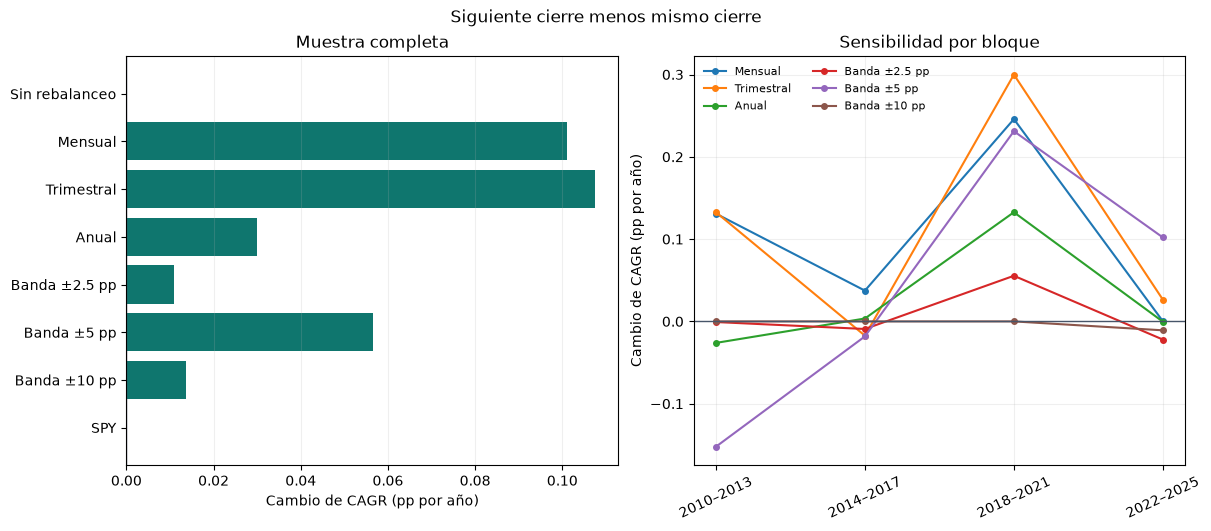

In [43]:
resultados_ejecucion_periodos = {
    periodo: evaluar_modos_ejecucion(precios.loc[inicio:fin])
    for periodo, (inicio, fin) in SUBPERIODOS.items()
}
resumen_ejecucion_periodos = pd.DataFrame([
    {"Periodo": periodo, "Ejecución": modo, "Estrategia": nombre,
     **resumir_backtest(resultado).to_dict()}
    for periodo, modos in resultados_ejecucion_periodos.items()
    for modo, estrategias in modos.items()
    for nombre, resultado in estrategias.items()
]).set_index(["Periodo", "Ejecución", "Estrategia"])
delta_cagr_periodos = (
    resumen_ejecucion_periodos.xs("Siguiente cierre", level="Ejecución")["CAGR"]
    - resumen_ejecucion_periodos.xs("Mismo cierre", level="Ejecución")["CAGR"]
).unstack("Estrategia").reindex(index=SUBPERIODOS, columns=orden_ejecucion) * 100
display(delta_cagr_periodos.style.format("{:+.3f}").set_caption(
    "Cambio de CAGR por retrasar la ejecución (pp por año)"
))

fig, ejes = plt.subplots(1, 2, figsize=(12, 5.2), layout="constrained")
valores_delta = comparacion_ejecucion["Cambio CAGR (pp)"]
ejes[0].barh(valores_delta.index, valores_delta,
             color=["#0f766e" if x >= 0 else "#be185d" for x in valores_delta])
ejes[0].invert_yaxis()
ejes[0].axvline(0, color="#475569", lw=1)
ejes[0].set(title="Muestra completa", xlabel="Cambio de CAGR (pp por año)")
ejes[0].grid(axis="x", alpha=.2)
for nombre in politicas_ejecucion:
    if nombre != "Sin rebalanceo":
        ejes[1].plot(delta_cagr_periodos.index, delta_cagr_periodos[nombre],
                     marker="o", ms=4, label=nombre)
ejes[1].axhline(0, color="#475569", lw=1)
ejes[1].set(title="Sensibilidad por bloque", ylabel="Cambio de CAGR (pp por año)")
ejes[1].tick_params(axis="x", rotation=25)
ejes[1].legend(fontsize=8, ncol=2, frameon=False)
ejes[1].grid(alpha=.2)
fig.suptitle("Siguiente cierre menos mismo cierre")
plt.show()

In [44]:
print("Resultados de la investigación de ejecución:")
for nombre in ["Mensual", banda_ejecucion_principal]:
    fila = comparacion_ejecucion.loc[nombre]
    print(f"{nombre}: CAGR {fila['CAGR mismo cierre']:.2%} → {fila['CAGR siguiente cierre']:.2%}; "
          f"cambio {fila['Cambio CAGR (pp)']:+.3f} pp; "
          f"rebalanceos {fila['Rebalanceos mismo cierre']:.0f} → {fila['Rebalanceos siguiente cierre']:.0f}.")
mayor_impacto = comparacion_ejecucion["Cambio CAGR (pp)"].abs().idxmax()
print(f"Mayor cambio absoluto de CAGR en la muestra completa: {mayor_impacto}, "
      f"{comparacion_ejecucion.loc[mayor_impacto, 'Cambio CAGR (pp)']:+.3f} pp por año.")
print(f"Cambios por bloque entre {delta_cagr_periodos.to_numpy().min():+.3f} y "
      f"{delta_cagr_periodos.to_numpy().max():+.3f} pp por año.")
print("El retraso puede favorecer o perjudicar según el camino de los precios; no es un costo fijo adicional.")

Resultados de la investigación de ejecución:
Mensual: CAGR 8.88% → 8.98%; cambio +0.101 pp; rebalanceos 191 → 191.
Banda ±5 pp: CAGR 9.15% → 9.21%; cambio +0.057 pp; rebalanceos 11 → 12.
Mayor cambio absoluto de CAGR en la muestra completa: Trimestral, +0.107 pp por año.
Cambios por bloque entre -0.152 y +0.300 pp por año.
El retraso puede favorecer o perjudicar según el camino de los precios; no es un costo fijo adicional.


## 8. Rendimiento ajustado por riesgo con una referencia histórica en USD

El crecimiento se complementa con el exceso de rendimiento sobre la columna
**RF diaria de Kenneth R. French**. La [documentación del proveedor](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html)
identifica la tasa de letras de un mes de Ibbotson hasta mayo de 2024 y el índice
ICE BofA US 1-Month Treasury Bill desde junio de 2024. La copia local documenta
la versión de la base CRSP de agosto de 2026 y conserva su huella SHA-256.

RF se publica en porcentaje diario por sesión: se convierte mediante **RF / 100**,
sin dividir otra vez entre 252 ni añadir interés de fin de semana. Se utiliza
el dato fechado al final del intervalo entre cierres. La precisión publicada
de 0.01 puntos porcentuales diarios puede redondear tasas pequeñas a cero.
La referencia se utiliza para evaluar resultados y no interviene en las señales.

Para $e_t=r_t-r_{f,t}$ y $P=252$:

$$\operatorname{Sharpe}=\sqrt{P}\,\frac{\bar e}{s(e)},\qquad
\operatorname{Sortino}=\sqrt{P}\,\frac{\bar e}
{\sqrt{\frac{1}{N}\sum_{t=1}^{N}\min(e_t,0)^2}}.$$

Sharpe utiliza desviación estándar muestral (`ddof=1`) del exceso, siguiendo
la formulación de [Sharpe (1994)](https://web.stanford.edu/~wfsharpe/art/sr/sr.htm).
Sortino utiliza RF como objetivo diario y promedia las desviaciones negativas
cuadráticas sobre **todos** los intervalos, dejando cero en los restantes, conforme
al [documento metodológico de Rollinger y Hoffman](https://www.cmegroup.com/content/dam/cmegroup/education/files/sortino-a-sharper-ratio.pdf).
Un denominador nulo se presenta como no definido (`n.d.`).

La raíz de 252 es una convención de anualización cuya interpretación puede
verse afectada por dependencia temporal. El exceso medio anualizado es aritmético
y no equivale a restar una tasa anual al CAGR. Los ratios complementan el análisis
de riqueza, caídas y composición; no los sustituyen.

### Tratamiento de entrada y referencia diaria

Para incluir todos los cargos sin crear una sesión ficticia, el primer rendimiento
real se define como $r_1=V_1/C_0-1$, donde $C_0$ es el capital anterior a la compra
y $V_1$ el patrimonio al segundo cierre. Los intervalos siguientes usan
$V_t/V_{t-1}-1$. Así se conserva la identidad:

$$\prod_t(1+r_t)=V_{\mathrm{final}}/C_0.$$

Las volatilidades anteriores excluían el registro aislado de entrada; las nuevas
métricas incluyen ese costo en el primer intervalo. El calendario de RF debe
coincidir exactamente con las fechas de precios: una ausencia genera error y
no se rellena con cero. La comprobación de la huella del CSV detecta cambios
respecto de la metadata guardada.

Los **4,023 intervalos** de evaluación acumulan un crecimiento de la referencia
RF de **24.57%**, equivalente a **1.38% geométrico anual** sobre la duración de
la muestra. Esa referencia no incluye costos de implementación. Los datos son
una versión retrospectiva; no se garantiza que coincidan con los publicados
en cada fecha histórica.

In [45]:
# Métricas ajustadas por riesgo: referencia diaria y costos de entrada.
import numpy as np
import pandas as pd


def _validar_indice_diario(indice, minimo):
    if (not isinstance(indice, pd.DatetimeIndex) or indice.hasnans
            or len(indice) < minimo or not indice.is_unique
            or not indice.is_monotonic_increasing):
        raise ValueError("Se requieren fechas válidas, únicas y ordenadas.")


def alinear_rf_diario(fechas_precios, rf_pct):
    """RF publicada en porcentaje diario; coincidencia estricta sin rellenar huecos."""
    _validar_indice_diario(fechas_precios, 3)
    if not isinstance(rf_pct, pd.Series):
        raise ValueError("RF debe ser una serie con fechas.")
    _validar_indice_diario(rf_pct.index, 3)
    valores = rf_pct.to_numpy(dtype=float)
    if not np.isfinite(valores).all() or (valores <= -100).any():
        raise ValueError("RF debe ser finita y mayor que -100 por ciento.")
    referencia = rf_pct.loc[fechas_precios[0]:fechas_precios[-1]]
    if not referencia.index.equals(fechas_precios):
        raise ValueError("El calendario de RF no coincide exactamente con los precios.")
    return (referencia.reindex(fechas_precios[1:]).astype(float) / 100).rename("RF")


def rendimientos_netos_con_entrada(resultado):
    """Integra la compra inicial en el primer intervalo real de mercado."""
    patrimonio = resultado["patrimonio"]
    capital = resultado["capital_inicial"]
    if not isinstance(patrimonio, pd.Series):
        raise ValueError("El patrimonio debe ser una serie con fechas.")
    _validar_indice_diario(patrimonio.index, 3)
    if (isinstance(capital, (bool, np.bool_))
            or not isinstance(capital, (int, float, np.integer, np.floating))
            or not np.isfinite(capital) or capital <= 0
            or not np.isfinite(patrimonio.to_numpy(dtype=float)).all()
            or (patrimonio <= 0).any()):
        raise ValueError("Capital y patrimonio deben ser positivos y finitos.")
    retornos = patrimonio.pct_change(fill_method=None).iloc[1:].copy()
    retornos.iloc[0] = patrimonio.iloc[1] / capital - 1
    return retornos.rename("Rendimiento neto")


def calcular_ratios(rendimientos, rf, periodos_anuales=252):
    """Sharpe y Sortino sobre excesos diarios, con RF como objetivo variable."""
    if not isinstance(rendimientos, pd.Series) or not isinstance(rf, pd.Series):
        raise ValueError("Rendimientos y RF deben ser series con fechas.")
    _validar_indice_diario(rendimientos.index, 2)
    _validar_indice_diario(rf.index, 2)
    if not rendimientos.index.equals(rf.index):
        raise ValueError("Rendimientos y RF deben tener exactamente el mismo índice.")
    if (isinstance(periodos_anuales, (bool, np.bool_))
            or not isinstance(periodos_anuales, (int, float, np.integer, np.floating))
            or not np.isfinite(periodos_anuales) or periodos_anuales <= 0):
        raise ValueError("La anualización requiere un número positivo y finito.")
    r, f = rendimientos.to_numpy(dtype=float), rf.to_numpy(dtype=float)
    if (not np.isfinite(r).all() or not np.isfinite(f).all()
            or (r <= -1).any() or (f <= -1).any()):
        raise ValueError("Los rendimientos y RF deben ser finitos y mayores que -1.")
    exceso = r - f
    media = exceso.mean()
    desviacion = exceso.std(ddof=1)
    downside = np.sqrt(np.mean(np.minimum(exceso, 0) ** 2))
    raiz = np.sqrt(periodos_anuales)
    return pd.Series({
        "Sharpe": raiz * media / desviacion if desviacion > 1e-14 else np.nan,
        "Sortino": raiz * media / downside if downside > 1e-14 else np.nan,
        "Exceso medio anualizado": media * periodos_anuales,
        "Volatilidad del exceso": desviacion * raiz,
        "Downside anualizado": downside * raiz,
        "Intervalos": len(exceso),
    })

In [46]:
import hashlib
import json

ruta_rf = carpeta / "rf_diario_usd.csv"
metadata_rf = json.loads((carpeta / "rf_diario_usd_metadata.json").read_text(encoding="utf-8"))
if hashlib.sha256(ruta_rf.read_bytes()).hexdigest() != metadata_rf["csv_sha256"]:
    raise ValueError("El archivo RF cambió respecto de su metadata; regenerar con scripts/prepare_risk_free.py.")
rf_publicada = pd.read_csv(ruta_rf, index_col="Date", parse_dates=["Date"])["RF_pct"]
rf_alineada = alinear_rf_diario(precios.index, rf_publicada)
anios_rf = (precios.index[-1] - precios.index[0]).days / 365.25
crecimiento_rf = (1 + rf_alineada).prod()
print(f"Fuente: {metadata_rf['provider']} | versión: {metadata_rf['source_vintage']}")
print(f"RF local: {len(rf_publicada):,} fechas; evaluación: {len(rf_alineada):,} intervalos.")
print(f"Referencia RF: crecimiento acumulado {crecimiento_rf - 1:.2%}; "
      f"tasa geométrica anual equivalente {crecimiento_rf ** (1 / anios_rf) - 1:.2%}.")
print("Unidades y calendario verificados. RF es una referencia teórica, sin costos de implementación.")

Fuente: Kenneth R. French Data Library | versión: This file was created by using the 202608 CRSP database.
RF local: 4,024 fechas; evaluación: 4,023 intervalos.
Referencia RF: crecimiento acumulado 24.57%; tasa geométrica anual equivalente 1.38%.
Unidades y calendario verificados. RF es una referencia teórica, sin costos de implementación.


,CAGR,Máxima caída,Sharpe,Sortino,Exceso medio anualizado,Volatilidad del exceso,Downside anualizado
Estrategia,,,,,,,
Sin rebalanceo,9.42%,-25.95%,0.712,0.991,8.33%,11.70%,8.40%
Mensual,8.98%,-21.03%,0.778,1.094,7.74%,9.94%,7.07%
Trimestral,9.03%,-21.19%,0.784,1.104,7.77%,9.92%,7.04%
Anual,8.96%,-20.96%,0.785,1.102,7.71%,9.81%,6.99%
Banda ±2.5 pp,9.02%,-21.22%,0.775,1.091,7.78%,10.04%,7.13%
Banda ±5 pp,9.21%,-21.36%,0.790,1.116,7.95%,10.07%,7.13%
Banda ±10 pp,9.18%,-21.19%,0.783,1.096,7.94%,10.14%,7.24%
SPY,13.90%,-33.72%,0.764,1.073,13.15%,17.21%,12.26%


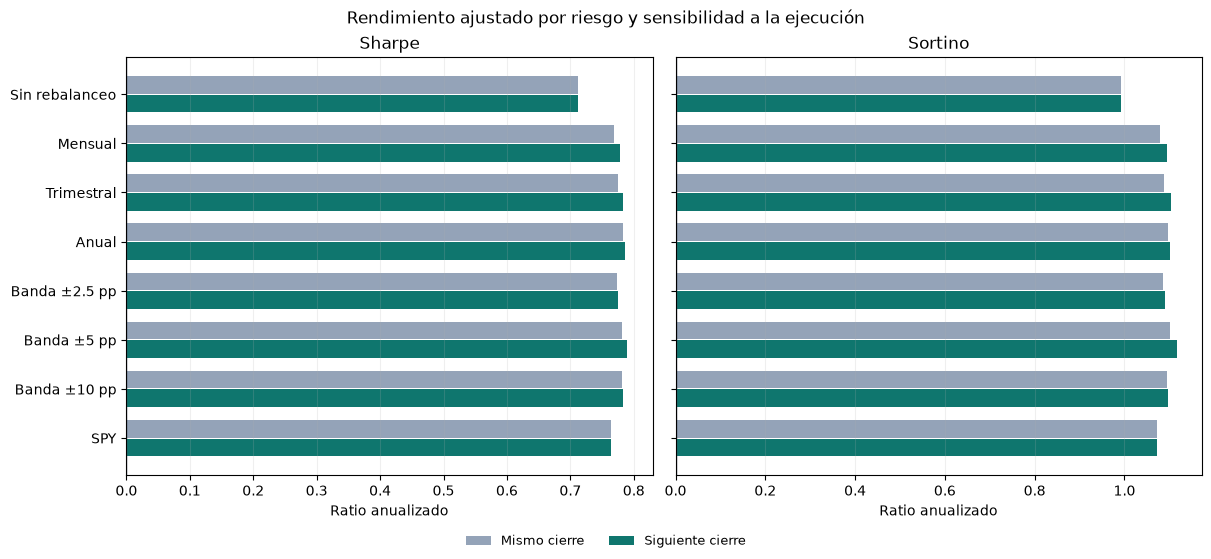

In [47]:
def resumen_riesgo_resultado(resultado):
    retornos = rendimientos_netos_con_entrada(resultado)
    referencia = alinear_rf_diario(resultado["patrimonio"].index, rf_publicada)
    np.testing.assert_allclose(
        (1 + retornos).prod(),
        resultado["patrimonio"].iloc[-1] / resultado["capital_inicial"], rtol=1e-10,
    )
    metricas = calcular_ratios(retornos, referencia)
    resumen = resumir_backtest(resultado)
    return pd.concat([resumen[["CAGR", "Máxima caída", "Costos pagados (USD)"]], metricas])


riesgo_ejecucion = pd.concat({
    modo: pd.DataFrame({nombre: resumen_riesgo_resultado(resultado)
                       for nombre, resultado in estrategias.items()}).T
    for modo, estrategias in resultados_ejecucion.items()
}, names=["Ejecución", "Estrategia"])
riesgo_diferido = riesgo_ejecucion.loc["Siguiente cierre"].reindex(orden_ejecucion)
columnas_riesgo = ["CAGR", "Máxima caída", "Sharpe", "Sortino",
                  "Exceso medio anualizado", "Volatilidad del exceso", "Downside anualizado"]
formatos_riesgo = {col: "{:.3f}" if col in ["Sharpe", "Sortino"] else "{:.2%}"
                  for col in columnas_riesgo}
display(riesgo_diferido[columnas_riesgo].style.format(formatos_riesgo, na_rep="n.d.").set_caption(
    "Riesgo ajustado por RF histórica: ejecución al siguiente cierre, neto de costos"
))

fig, ejes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True, layout="constrained")
y = np.arange(len(orden_ejecucion))
for ax, metrica in zip(ejes, ["Sharpe", "Sortino"]):
    for offset, (modo, color) in zip([-.19, .19], [("Mismo cierre", "#94a3b8"), ("Siguiente cierre", "#0f766e")]):
        valores = riesgo_ejecucion.loc[modo, metrica].reindex(orden_ejecucion)
        ax.barh(y + offset, valores, height=.36, label=modo, color=color)
    ax.set_yticks(y, orden_ejecucion)
    ax.axvline(0, color="#475569", lw=1)
    ax.set(title=metrica, xlabel="Ratio anualizado")
    ax.grid(axis="x", alpha=.2)
ejes[0].invert_yaxis()
handles, labels = ejes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False, fontsize=9)
fig.suptitle("Rendimiento ajustado por riesgo y sensibilidad a la ejecución")
plt.show()

### Resultados ajustados por riesgo y consistencia temporal

En la muestra completa y con **ejecución al siguiente cierre**, se obtiene:

| Política | CAGR | Máxima caída | Sharpe | Sortino |
|---|---:|---:|---:|---:|
| Sin rebalanceo | 9.42% | −25.95% | 0.712 | 0.991 |
| Mensual | 8.98% | −21.03% | 0.778 | 1.094 |
| Banda ±5 pp | 9.21% | −21.36% | 0.790 | 1.116 |
| SPY | 13.90% | −33.72% | 0.764 | 1.073 |

La banda ±5 pp registra el mayor Sharpe y Sortino entre las políticas evaluadas,
pero su ventaja frente al mensual es de solo **0.012 y 0.022**, respectivamente.
Además, supera al mensual en ambos ratios en **2 de los 4 bloques**, calculando
RF sobre las fechas exactas de cada inversión reiniciada. La ventaja agregada
no es uniforme en el tiempo.

SPY alcanza el mayor CAGR y soporta una caída mayor; mantener los cuatro activos
sin rebalancear crece más que las políticas mensual y de banda principal, pero
obtiene menores ratios. La comparación demuestra que ordenar por crecimiento
y ordenar por rendimiento ajustado por riesgo responde a objetivos distintos.

No se estiman significancias estadísticas ni se reajusta el umbral para maximizar
estos resultados. Las diferencias describen la muestra y deben valorarse junto
con la deriva de pesos y la actividad que cada regla exige.

Estrategia,Sin rebalanceo,Mensual,Trimestral,Anual,Banda ±2.5 pp,Banda ±5 pp,Banda ±10 pp,SPY
Periodo,,,,,,,,
2010–2013,0.912,0.946,0.958,0.945,0.937,0.940,0.912,0.933
2014–2017,1.021,1.060,1.035,1.035,1.017,1.050,1.021,1.011
2018–2021,0.869,0.902,0.929,0.914,0.908,0.910,0.869,0.804
2022–2025,0.494,0.359,0.355,0.390,0.371,0.397,0.416,0.435


Estrategia,Sin rebalanceo,Mensual,Trimestral,Anual,Banda ±2.5 pp,Banda ±5 pp,Banda ±10 pp,SPY
Periodo,,,,,,,,
2010–2013,1.305,1.359,1.382,1.356,1.350,1.351,1.305,1.319
2014–2017,1.441,1.507,1.469,1.469,1.441,1.489,1.441,1.437
2018–2021,1.170,1.222,1.263,1.232,1.234,1.249,1.170,1.103
2022–2025,0.709,0.513,0.508,0.557,0.530,0.569,0.595,0.624


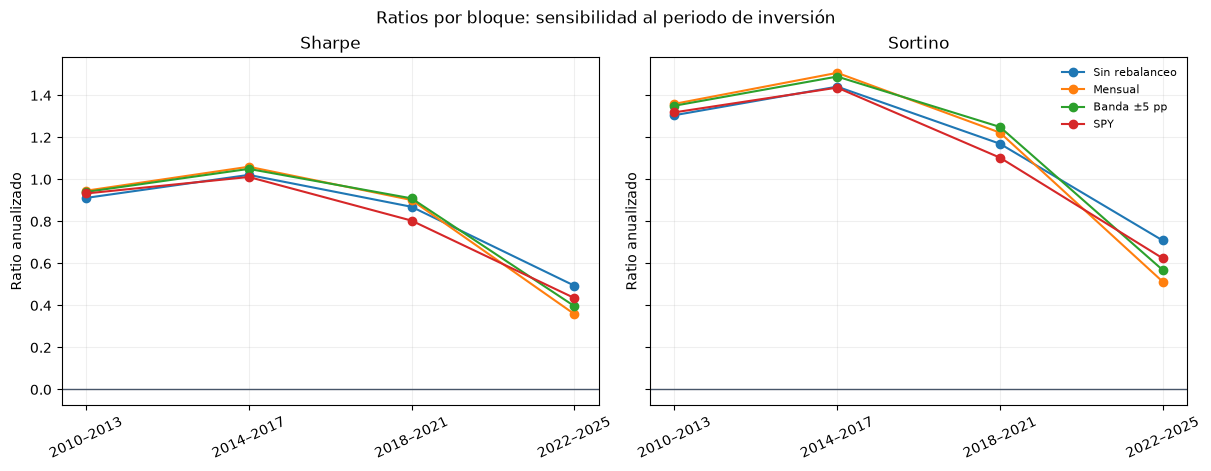

In [48]:
riesgo_periodos = pd.DataFrame([
    {"Periodo": periodo, "Estrategia": nombre,
     **resumen_riesgo_resultado(resultado).to_dict()}
    for periodo, modos in resultados_ejecucion_periodos.items()
    for nombre, resultado in modos["Siguiente cierre"].items()
]).set_index(["Periodo", "Estrategia"])
tablas_ratios_periodos = {}
for metrica in ["Sharpe", "Sortino"]:
    tabla = riesgo_periodos[metrica].unstack("Estrategia").reindex(index=SUBPERIODOS, columns=orden_ejecucion)
    tablas_ratios_periodos[metrica] = tabla
    display(tabla.style.format("{:.3f}", na_rep="n.d.").set_caption(
        f"{metrica} por bloque — siguiente cierre, neto de costos"
    ))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True, layout="constrained")
for ax, metrica in zip(ejes, ["Sharpe", "Sortino"]):
    for nombre in ["Sin rebalanceo", "Mensual", banda_ejecucion_principal, "SPY"]:
        ax.plot(tablas_ratios_periodos[metrica].index, tablas_ratios_periodos[metrica][nombre],
                marker="o", label=nombre)
    ax.axhline(0, color="#475569", lw=1)
    ax.set(title=metrica, ylabel="Ratio anualizado")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(alpha=.2)
ejes[1].legend(frameon=False, fontsize=8)
fig.suptitle("Ratios por bloque: sensibilidad al periodo de inversión")
plt.show()

In [49]:
print("Resultados de la investigación de rendimiento ajustado por riesgo:")
for nombre in ["Sin rebalanceo", "Mensual", banda_ejecucion_principal, "SPY"]:
    fila = riesgo_diferido.loc[nombre]
    print(f"{nombre}: CAGR {fila['CAGR']:.2%}; caída {fila['Máxima caída']:.2%}; "
          f"Sharpe {fila['Sharpe']:.3f}; Sortino {fila['Sortino']:.3f}.")
for metrica in ["Sharpe", "Sortino"]:
    valores = riesgo_diferido[metrica].dropna()
    if not valores.empty:
        print(f"Mayor {metrica} descriptivo en la muestra completa: {valores.idxmax()} ({valores.max():.3f}).")
    principal_bloques = tablas_ratios_periodos[metrica][banda_ejecucion_principal]
    mensual_bloques = tablas_ratios_periodos[metrica]["Mensual"]
    validos = principal_bloques.notna() & mensual_bloques.notna()
    superiores = ((principal_bloques - mensual_bloques > 1e-10) & validos).sum()
    print(f"{banda_ejecucion_principal} supera al mensual en {metrica} en {superiores} de {validos.sum()} bloques evaluables.")
print("La banda principal se conserva por diseño: estos resultados no se usan para ajustar su umbral.")
for metrica in ["Sharpe", "Sortino"]:
    brecha = riesgo_diferido.loc[banda_ejecucion_principal, metrica] - riesgo_diferido.loc["Mensual", metrica]
    print(f"Diferencia de {metrica} de la banda principal frente al mensual: {brecha:+.3f}.")
print("La ventaja en la muestra completa debe leerse junto con su variación entre bloques; "
      "no demuestra superioridad estadística ni garantiza resultados futuros.")

Resultados de la investigación de rendimiento ajustado por riesgo:
Sin rebalanceo: CAGR 9.42%; caída -25.95%; Sharpe 0.712; Sortino 0.991.
Mensual: CAGR 8.98%; caída -21.03%; Sharpe 0.778; Sortino 1.094.
Banda ±5 pp: CAGR 9.21%; caída -21.36%; Sharpe 0.790; Sortino 1.116.
SPY: CAGR 13.90%; caída -33.72%; Sharpe 0.764; Sortino 1.073.
Mayor Sharpe descriptivo en la muestra completa: Banda ±5 pp (0.790).
Banda ±5 pp supera al mensual en Sharpe en 2 de 4 bloques evaluables.
Mayor Sortino descriptivo en la muestra completa: Banda ±5 pp (1.116).
Banda ±5 pp supera al mensual en Sortino en 2 de 4 bloques evaluables.
La banda principal se conserva por diseño: estos resultados no se usan para ajustar su umbral.
Diferencia de Sharpe de la banda principal frente al mensual: +0.012.
Diferencia de Sortino de la banda principal frente al mensual: +0.022.
La ventaja en la muestra completa debe leerse junto con su variación entre bloques; no demuestra superioridad estadística ni garantiza resultados f

## Conclusiones generales y cierre del proyecto

El estudio muestra que la diversificación, el rebalanceo y la ejecución modifican
dimensiones distintas del resultado. La asignación igualitaria con rebalanceo
mensual reduce volatilidad y caída máxima frente a SPY, a cambio de menor CAGR.
Con el supuesto del mismo cierre, sus cifras son **9.95% de volatilidad y −21.10%
de caída**, frente a **17.21% y −33.72%** de SPY; el CAGR es **8.88% frente a 13.90%**.

Mantener posiciones logra el mayor CAGR entre las políticas de calendario,
pero termina con **47.49% en SPY**. Su ventaja incorpora una exposición distinta
de la asignación inicial. Por ello, el rebalanceo se interpreta principalmente
como una política de control de composición, cuyo valor depende del grado de
deriva aceptable y de su costo de implementación.

Las bandas reducen la actividad de forma sustancial. Con ejecución diferida,
la banda ±5 pp registra **12 rebalanceos frente a 191 mensuales**, CAGR de
**9.21% frente a 8.98%**, y ratios Sharpe/Sortino de **0.790/1.116 frente a
0.778/1.094**. Esa ventaja agregada convive con una caída ligeramente más profunda
y con superioridad en ambos ratios en solo **dos de cuatro subperiodos**.
La evidencia respalda su consideración como alternativa de gestión, sin demostrar
que el umbral sea óptimo ni que su ventaja vaya a persistir.

### Límites de la evidencia

El alcance de las conclusiones está determinado por el diseño:

- **Selección y periodo:** cuatro instrumentos fijados para este estudio y un
  historial ya observado. No se analiza un universo amplio ni se reserva una
  muestra posterior para validar una decisión seleccionada con estos resultados.
- **Dependencia de las observaciones:** las ventanas móviles se solapan y los
  escenarios de costos comparten precios. Sus cuotas no son probabilidades futuras.
- **Ejecución:** cierres ajustados, fracciones, costos proporcionales y ausencia
  de spread, deslizamiento, liquidez e impacto de mercado modelados por separado.
  La espera de una sesión no convierte el backtest en un registro de operaciones reales.
- **Patrimonio y moneda:** sin aportaciones, retiros, impuestos ni liquidación
  terminal. Los resultados son nominales en USD y no incluyen inflación ni efecto USD/MXN.
- **Datos y métricas:** ajustes y revisiones del proveedor, RF retrospectiva y
  anualización convencional. Sharpe y Sortino no resumen todos los riesgos de
  pérdida, concentración o persistencia de las caídas.

### Entrega y reproducibilidad

Esta versión completa las ocho etapas previstas y deja un motor con registro
de operaciones, controles contables y **51 pruebas automatizadas** de sus reglas
y métricas. El código, tablas y gráficas constituyen la evidencia calculada;
los textos sintetizan la ejecución documentada y requieren revisión si se
modifican los parámetros.

El [README](README.md) describe instalación y ejecución. Los archivos de `data/`
permiten reproducir la muestra; `rf_diario_usd_metadata.json` documenta fuente,
versión, unidades y huellas. `scripts/prepare_risk_free.py` reconstruye RF desde
el ZIP local, mientras `--refresh` solicita una nueva versión que puede modificar
los resultados. El cierre del proyecto consiste en esta evaluación histórica
documentada, con sus decisiones de diseño y sus límites explícitos.